In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
from scipy.optimize import fsolve
from scipy.optimize import least_squares
from matplotlib.ticker import MultipleLocator

# Volume ratio

Let's start by reading the trial data.

In [2]:
methods = pd.read_csv('methods.csv', index_col='id')
methods.tail()

,description,notes
id,,
5,Brass manifold (2 phases),NaN
6,Brass manifold (3 phases),Started opening all valves before each trial
7,Positive pressure,NaN
8,Brass manifold (2 phases),After re-assembly
9,Brass manifold (2 phases),Automatic version


In [3]:
samples = pd.read_csv('samples.csv', index_col='id')
samples.tail()

,date,weight,volume,bag_id,grinder_cal_id,grind_setting,shot_id,depth_id,method_id,description,notes
id,,,,,,,,,,,
1049,2025-03-09,269.25,34.05,NaN,NaN,NaN,NaN,NaN,9,75 balls (old),NaN
1050,2025-03-10,18.11,NaN,161.0,14.0,2.8,2013.0,1487.0,9,Boa Bedegelo (2.80) ground,NaN
1051,2025-03-10,18.10,NaN,161.0,14.0,2.8,2014.0,1488.0,9,Boa Bedegelo (2.80) ground,NaN
1052,2025-03-10,0.00,0.00,NaN,NaN,NaN,NaN,NaN,9,Empty,NaN
1053,2025-03-10,269.36,34.05,NaN,NaN,NaN,NaN,NaN,9,75 balls (old),NaN


In [4]:
trials = pd.read_csv('trials.csv', index_col='id')
trials.tail()

,sample_id,filename
id,,
3151,1052,trials/trial-3151.csv
3152,1052,trials/trial-3152.csv
3153,1053,trials/trial-3153.csv
3154,1053,trials/trial-3154.csv
3155,1053,trials/trial-3155.csv


There are a couple of incomplete trials here. Let's drop them.

In [5]:
trials = trials[[i not in [1451,1507,1525] for i in trials.index]]

For these experiments, two measurement technique were used. In the first technique, we have two chambers separated by a valve. One chamber is empty and the other chamber contains our sample. We start with a partial vacuum in the empty chamber and atmospheric pressure in the sample chamber, then we open the valve between the two chambers and measure the resulting change in pressure. Here's a typical plot showing the pressure change in the two chambers.

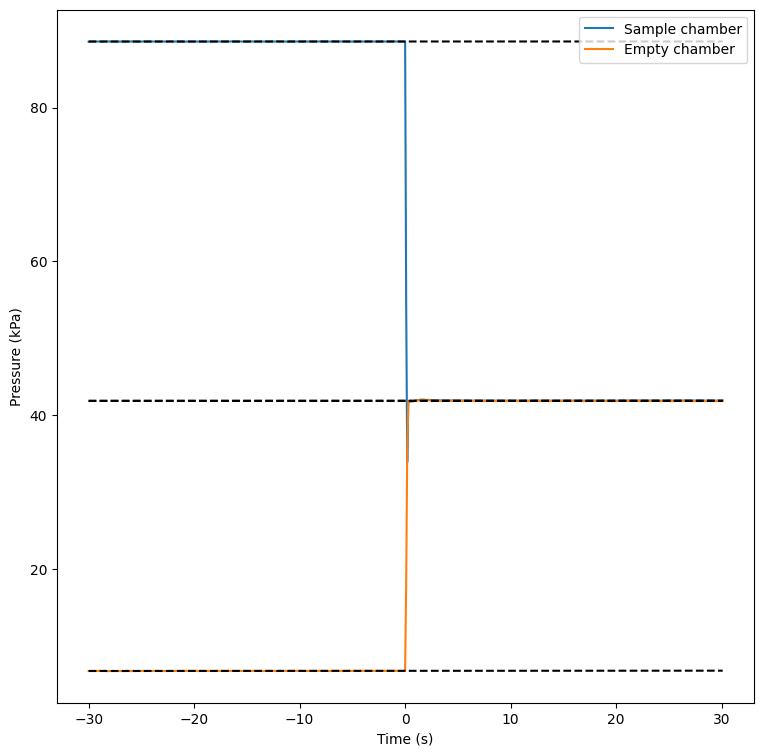

In [6]:
def pressure_func(x, m, b):
    return m * x + b

# Read the data
data = pd.read_csv(trials.loc[884].filename, header=0)

# Get linear fits
xs = data.time.values[data.time.values < -10]
ys = data.pres_1.values[data.time.values < -10]
fit_1 = curve_fit(pressure_func, xs, ys)

ys = data.pres_2.values[data.time.values < -10]
fit_2 = curve_fit(pressure_func, xs, ys)

xs = data.time.values[(data.time.values > 10) & (data.time.values <= 30)]
ys = data.pres_1.values[(data.time.values > 10) & (data.time.values <= 30)]
fit_1_prime = curve_fit(pressure_func, xs, ys)

xs = data.time.values[(data.time.values > 10) & (data.time.values <= 30)]
ys = data.pres_2.values[(data.time.values > 10) & (data.time.values <= 30)]
fit_2_prime = curve_fit(pressure_func, xs, ys)

# Create the figure
fig, ax = plt.subplots(figsize=(9,9))
fig.patch.set_facecolor('white')

# Plot data
ax.plot(data.time, data.pres_1, label='Sample chamber')
ax.plot(data.time, data.pres_2, label='Empty chamber')

# Plot the fits
ax.plot(data.time, pressure_func(data.time, *fit_1[0]), 'k--')
ax.plot(data.time, pressure_func(data.time, *fit_1_prime[0]), 'k--')

ax.plot(data.time, pressure_func(data.time, *fit_2[0]), 'k--')
ax.plot(data.time, pressure_func(data.time, *fit_2_prime[0]), 'k--')

# Set axis labels
ax.set_xlabel('Time (s)')
ax.set_ylabel('Pressure (kPa)')

# Draw legend
ax.legend(loc='upper right')

By fitting lines to the three equilibrium states, we can determine the change in pressure at the moment the valve is opened, and thus the ratio of the sample chamber volume to the empty chamber volume.

In [7]:
def vol_ratio_two_sensors(filename):
    # Read the data
    data = pd.read_csv(filename, header=0)
    
    # Get linear fits
    xs = data.time.values[data.time.values < -10]
    ys = data.pres_1.values[data.time.values < -10]
    pres_1 = pressure_func(0, *curve_fit(pressure_func, xs, ys)[0])

    ys = data.pres_2.values[data.time.values < -10]
    pres_2 = pressure_func(0, *curve_fit(pressure_func, xs, ys)[0])

    xs = data.time.values[(data.time.values > 10) & (data.time.values <= 30)]
    ys = data.pres_1.values[(data.time.values > 10) & (data.time.values <= 30)]
    pres_1_prime = pressure_func(0, *curve_fit(pressure_func, xs, ys)[0])

    ys = data.pres_2.values[(data.time.values > 10) & (data.time.values <= 30)]
    pres_2_prime = pressure_func(0, *curve_fit(pressure_func, xs, ys)[0])

    r = -(pres_2_prime - pres_2) / (pres_1_prime - pres_1)
    
    sigma_p = 0.0079
    sigma_r = np.sqrt(2 * (1 / (pres_2_prime - pres_2)**2 + 1 / (pres_1_prime - pres_1)**2)) * sigma_p * r

    # Volume ratio from y-intercepts
    return (r, sigma_r)


For the trial shown above, we have:

In [8]:
vol_ratio_two_sensors(trials.loc[884].filename)

(np.float64(0.751357184359704), np.float64(0.000299230422718325))

That is, the sample chamber has a volume $0.75136 \pm 0.00030$ times the volume of the empty chamber. The error calculation is based on the 0.0079 kPa resolution of the HSCDANN015PA2A3 sensor used in these experiments. Note that this isn't representative of the absolute accuracy of the sensor, but the assumption here is that offset and scaling errors errors common to both sensors will be cancelled out in the calculation of volume ratio.

The second technique used for these experiments uses a single chamber. In this technique, the sample is put into this chamber, then the volume is changed by some fixed amount. Again we measure the resulting change in pressure, this time using a single sensor. Here is a typical plot showing the change in pressure for a single chamber experiment.

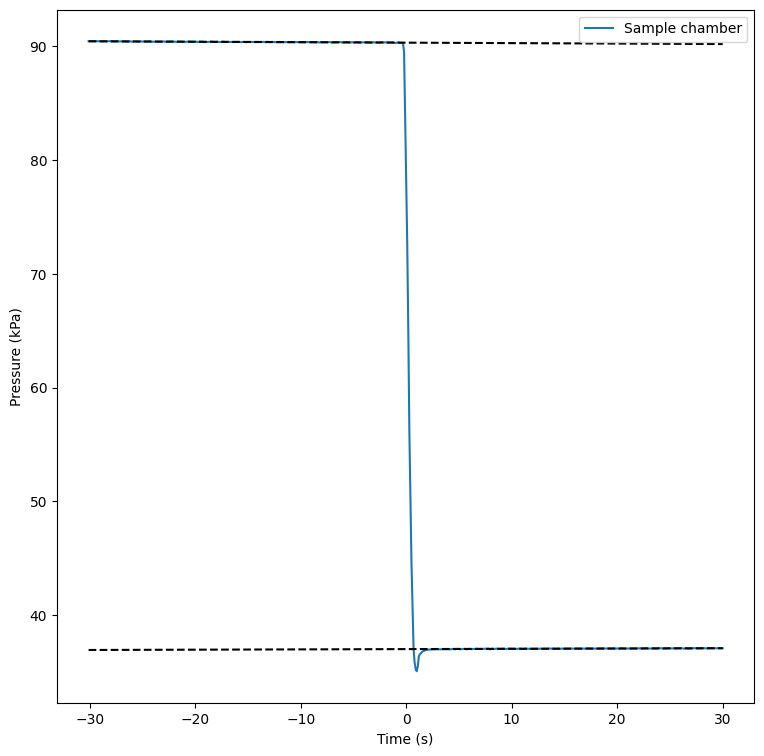

In [9]:
# Read the data
data = pd.read_csv(trials.loc[120].filename, header=0)

# Get linear fits
xs = data.time.values[data.time.values < -10]
ys = data.pres_1.values[data.time.values < -10]
fit_1 = curve_fit(pressure_func, xs, ys)

xs = data.time.values[data.time.values > 10]
ys = data.pres_1.values[data.time.values > 10]
fit_2 = curve_fit(pressure_func, xs, ys)

# Create the figure
fig, ax = plt.subplots(figsize=(9,9))
fig.patch.set_facecolor('white')

# Plot data
ax.plot(data.time, data.pres_1, label='Sample chamber')

# Plot the fits
ax.plot(data.time, pressure_func(data.time, *fit_1[0]), 'k--')
ax.plot(data.time, pressure_func(data.time, *fit_2[0]), 'k--')

# Set axis labels
ax.set_xlabel('Time (s)')
ax.set_ylabel('Pressure (kPa)')

# Draw legend
ax.legend(loc='upper right')

Again we can fit lines to the equilibrium states in order to determine the change in pressure when the chamber volume is changed, and thus the ratio of the sample chamber volumes.

In [10]:
def vol_ratio_one_sensor(filename):
    # Read the data
    data = pd.read_csv(filename, header=0)

    # Get linear fits
    xs = data.time.values[data.time.values < -10]
    ys = data.pres_1.values[data.time.values < -10]
    pres_1 = pressure_func(0, *curve_fit(pressure_func, xs, ys)[0])

    xs = data.time.values[data.time.values > 10]
    ys = data.pres_1.values[data.time.values > 10]
    pres_1_prime = pressure_func(0, *curve_fit(pressure_func, xs, ys)[0])

    r = -pres_1_prime / (pres_1_prime - pres_1)
    
    sigma_p = 0.0079
    sigma_r = np.sqrt(2 * (1 / pres_1_prime**2 + 1 / (pres_1_prime - pres_1)**2)) * sigma_p * r

    # Volume ratio from y-intercepts
    return (r, sigma_r)

For the trial shown above we have:

In [11]:
vol_ratio_one_sensor(trials.loc[120].filename)

(np.float64(0.6942124413672979), np.float64(0.0002551118775146742))

Let's associate each measurement method with one of these two techniques.

In [12]:
vol_ratio_methods = {1: vol_ratio_one_sensor,
                     2: vol_ratio_two_sensors,
                     3: vol_ratio_one_sensor,
                     4: vol_ratio_two_sensors,
                     5: vol_ratio_two_sensors,
                     6: vol_ratio_two_sensors,
                     7: vol_ratio_two_sensors,
                     8: vol_ratio_two_sensors,
                     9: vol_ratio_two_sensors}

Now we can calculate the volume ratio for each trial.

In [13]:
def row_func(row):
    method_id = samples.loc[row.sample_id].method_id
    row['vol_ratio'], row['sigma_vol_ratio'] = vol_ratio_methods[method_id](row.filename)
    return row

trials = trials.apply(row_func, axis=1)
trials.tail()

,sample_id,filename,vol_ratio,sigma_vol_ratio
id,,,,
3151,1052,trials/trial-3151.csv,0.993179,0.000524
3152,1052,trials/trial-3152.csv,0.994572,0.000525
3153,1053,trials/trial-3153.csv,0.734052,0.000397
3154,1053,trials/trial-3154.csv,0.734174,0.000400
3155,1053,trials/trial-3155.csv,0.735314,0.000400


# Outliers

Let's look for outliers in our calibration measurements. The calibration samples are the ones for which a volume has been specified.

In [14]:
# Get samples with valid volume
samples_w_vol = samples.dropna(subset='volume')

Now we plot the volume ratio for each trial associated with these samples.

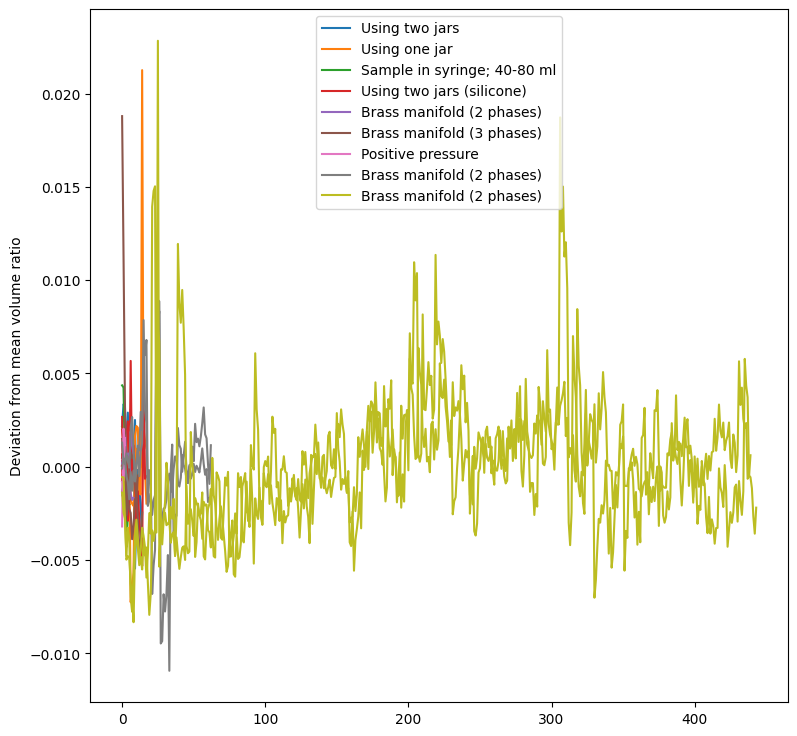

In [15]:
def plot_calibration():
    # Get color map
    method_colors = plt.colormaps['tab10'].colors
    
    # Create the figure
    fig, ax = plt.subplots(figsize=(9,9))
    fig.patch.set_facecolor('white')
    
    for i, method_id in enumerate(samples.method_id.unique()):
        # Get samples for this method
        samples_this_method = samples_w_vol[samples_w_vol.method_id == method_id]
        
        # Initialize label
        label = methods.loc[method_id].description
    
        for description in samples_this_method.description.unique():
            # Get samples with this description
            samples_this_desc = samples_this_method[samples_this_method.description == description]
    
            # Get trials for these samples
            trials_this_desc = trials[[s in samples_this_desc.index for s in trials.sample_id]]
            
            # Get volume ratios
            vol_ratios = trials_this_desc.vol_ratio
            
            # Get mean value of volume ratio
            mean_vol_ratio = vol_ratios.mean()
            
            # Plot deviation from mean
            ax.plot(range(len(vol_ratios)), vol_ratios - mean_vol_ratio,
                    label=label, color=method_colors[i])
            
            # Reset label
            label = None
    
    # Set axis labels
    ax.set_ylabel('Deviation from mean volume ratio')
    
    # Draw the legend
    plt.legend()

# Plot calibrations
plot_calibration()

There are a few outliers on the left. These are trials #93, #455, #456, and #457.

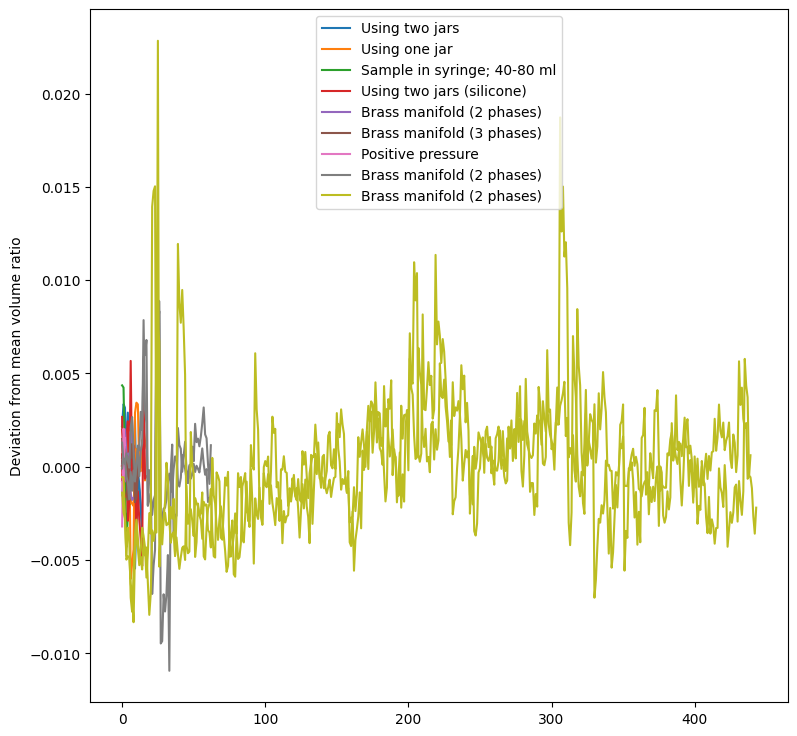

In [16]:
# Drop the trials
trials = trials.drop([93, 455, 456, 457])

# Plot calibrations
plot_calibration()

On the right, we have some wild swings in measurements using method 8. These occurred after a period of about 6 months without using the apparatus. I think what happened here is that I changed the way I handled the apparatus, so that I was touching the pressure sensor more than I used to and creating temperature-related errors. When I stopped touching the sensor, in the last 6 trials, the measurements seemed to become more stable.

C:\Users\crwpe\AppData\Local\Temp\ipykernel_18852\3238877015.py:7: FutureWarning: Logical ops (and, or, xor) between Pandas objects and dtype-less sequences (e.g. list, tuple) are deprecated and will raise in a future version. Wrap the object in a Series, Index, or np.array before operating instead.
  indices_to_drop = trials[id_mask & cal_mask].index


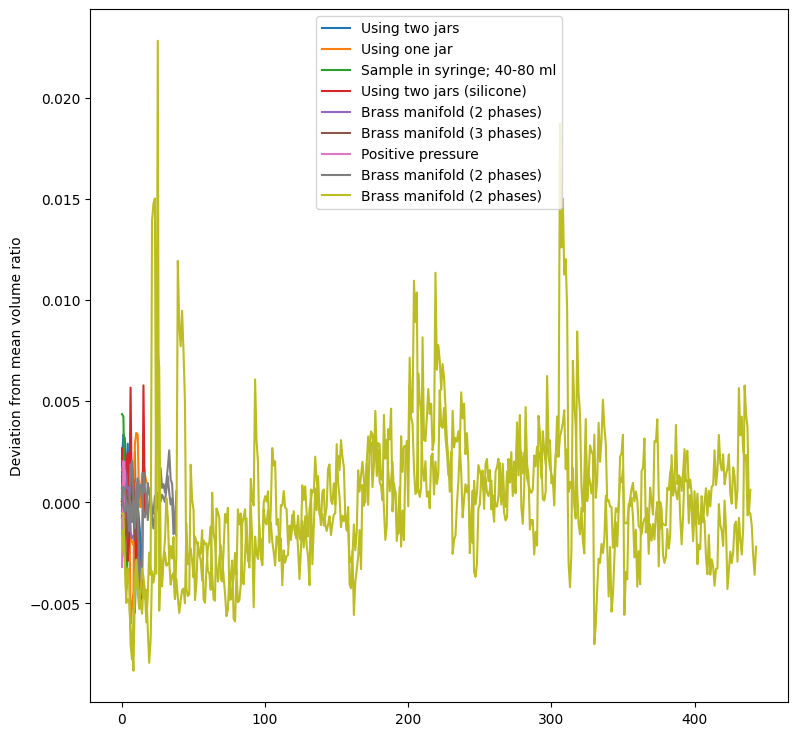

In [17]:
# Get calibration sample ids
cal_sample_ids = samples[~samples.volume.isna()].index

# Determine which trials to drop
id_mask = (trials.sample_id >= 248) & (trials.sample_id < 291)
cal_mask = [s in cal_sample_ids for s in trials.sample_id]
indices_to_drop = trials[id_mask & cal_mask].index

# Drop the trials
trials = trials.drop(indices_to_drop)

# Plot calibrations
plot_calibration()

There are some samples which were taken immediately after the beans were removed from the freezer. In hindsight it seems obvious, but it turns out that the volume measurements are very sensitive to temperature, as this has a major effect on the ideal gas law. Let's drop the samples in question.

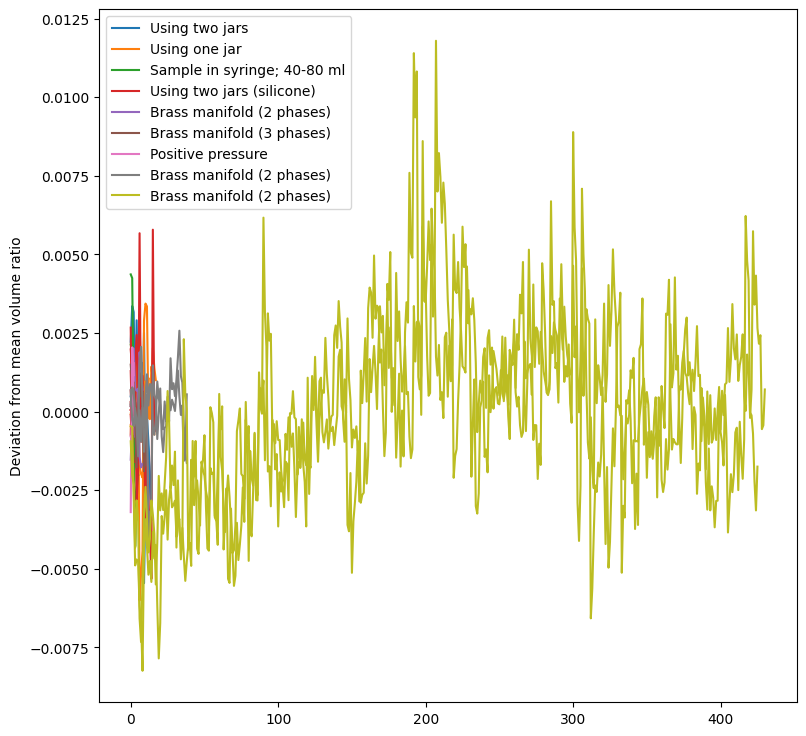

In [18]:
# Determine which trials to drop
samples_to_drop = [387, 395, 419, 421, 850, 851, 856, 857, # Empty
                   400]                                    # 75 balls (old)

# Drop the trials
trials = trials[[s not in samples_to_drop for s in trials.sample_id]]

# Plot calibrations
plot_calibration()

Looking at non-calibration trials, there are some trials on May 20, 2023, using the syringe, where I noticed the pressure with the plunger pushed in changed from one trial to the next.

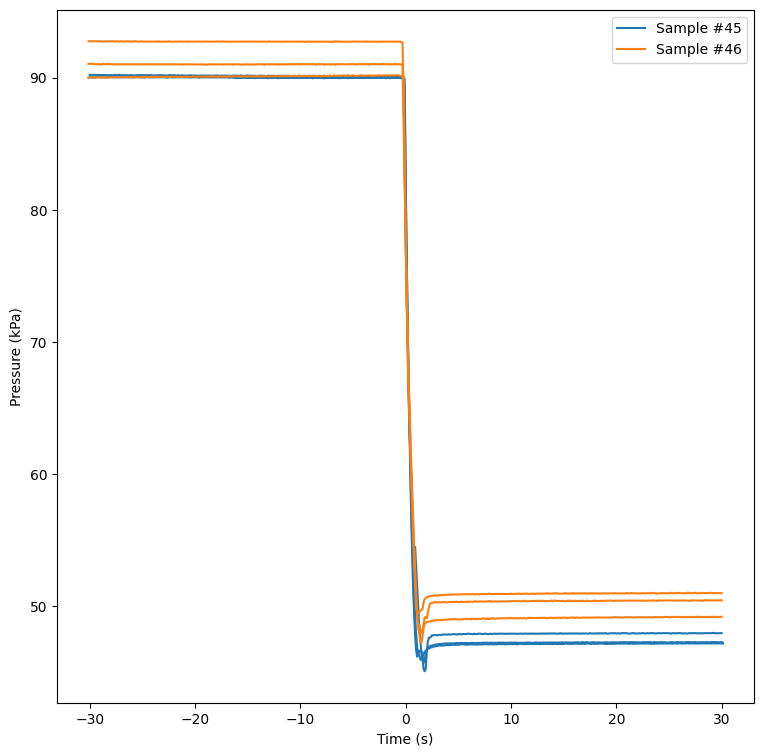

In [19]:
def plot_single_trial(index, color=None, label=None):
    # Read the data
    data = pd.read_csv(trials.loc[index].filename, header=0)

    # Plot data
    ax.plot(data.time, data.pres_1, c=color, label=label)

# Create the figure
fig, ax = plt.subplots(figsize=(9,9))
fig.patch.set_facecolor('white')

# Get color map
colors = plt.colormaps['tab10'].colors

# Plot the trials
label = 'Sample #45'
for i in [133, 134, 135]:
    plot_single_trial(i, color=colors[0], label=label)
    label = None

label = 'Sample #46'
for i in [136, 137, 138]:
    plot_single_trial(i, color=colors[1], label=label)
    label = None

# Set axis labels
ax.set_xlabel('Time (s)')
ax.set_ylabel('Pressure (kPa)')

# Draw legend
ax.legend(loc='upper right')

Each of these samples contains three trials which should be identical repetitions, but we see variation in the pressure change. There is no sign of leakage when the pluger is stationary, on either side of the transition, so in these cases I beleive the leakage was caused by the movement of the plunger.

In [20]:
# Drop the trials
trials = trials.drop([135, 137, 138])

There are some trials early on with the new gas pycnometer which seemed affected by an unknown glitch--maybe a bad USB power supply. Let's drop these.

In [21]:
# Drop the trials
trials = trials.drop([1172, 1180, 1181, 1311])

There are also some samples which were taken right after the beans were taken out of the freezer. Let's drop these as well.

In [22]:
# Drop the trials
trials = trials.drop(range(187, 199))
trials = trials.drop(range(2542, 2545))
trials = trials.drop(range(2560, 2563))
trials = trials.drop(range(2791,2794))

# Calibration

To calibrate the gas pycnometer, we take measurements either with the sample chamber empty, or with a sample of known volume in the chamber. For these experiments, the reference was a set of 3/8" steel balls whose volume was measured using water displacement.

Let's look at the spread in volume ratio measurements for the two references.

2 Empty 1.0220130721677323 0.002554959116492448 0.00038589670634195806
1 Empty 1.3607838810783957 0.0027754543612303847 0.0004922537931744577
3 Empty 1.0471640260780057 0.0036059665948763317 0.00036873658547571797
4 Empty 1.0217703784534757 0.002700225195293189 0.00038835628197448637
4 75 balls (old) 0.7585658036831369 0.0024785681161125627 0.0002935436203814346
5 Empty 1.0131923412161956 0.0010685486703128784 0.000395579289615871
5 75 balls (old) 0.7518334343223245 0.0013186292406297665 0.00030366858854794106
6 Empty 1.0135362141833595 0.0009898471497284608 0.0003931601899727257
6 75 balls (old) 0.7509108207259101 0.0010493162379466466 0.00030062280901092895
7 Empty 0.9986464881082391 0.002805261678584808 0.00048117258096231757
7 75 balls (old) 0.7424539936769387 0.0013325337277403624 0.00038072964571492923
8 Empty 1.014274312465125 0.0014161824577411475 0.0004007000912356683
8 75 balls (old) 0.7518543752190398 0.0007281585902374887 0.00030467271698210994
9 Empty 0.9963241440534477 0.

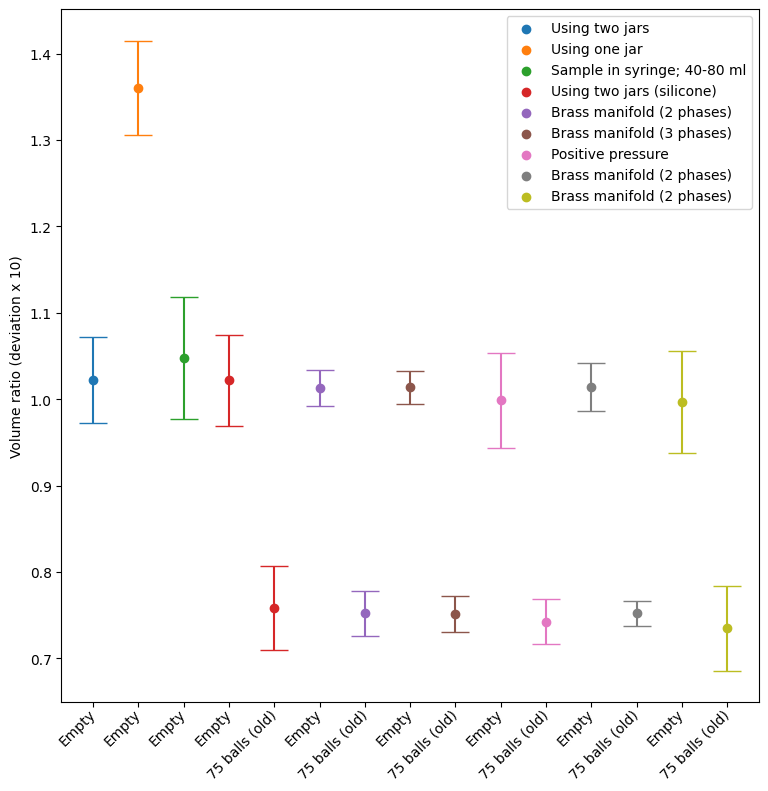

In [23]:
def rotate_tick_labels(ax, rotation=45, rotation_mode='anchor', 
                       horizontalalignment='right', verticalalignment='center'):
    for label in ax.get_xticklabels():
        label.set_rotation(rotation)
        label.set_rotation_mode(rotation_mode)
        label.set_horizontalalignment(horizontalalignment)
        label.set_verticalalignment(verticalalignment)

# Create the figure
fig, ax = plt.subplots(figsize=(9,9))
fig.patch.set_facecolor('white')

# Initialize ticks and labels
xticks = []
xlabels = []

for i, method_id in enumerate(samples.method_id.unique()):
    # Get samples for this method
    samples_this_method = samples_w_vol[samples_w_vol.method_id == method_id]
    
    # Initialize label
    label = methods.loc[method_id].description

    for description in ['Empty', '75 balls (old)']:
        # Get samples with this description
        samples_this_desc = samples_this_method[samples_this_method.description == description]
        
        # Get trials for these samples
        trials_this_desc = trials[[s in samples_this_desc.index for s in trials.sample_id]]
    
        if not trials_this_desc.empty:
            # Update ticks and labels
            x = len(xticks)
            xticks.append(x)
            xlabels.append(description)
            
            # Get volume ratios
            vol_ratios = trials_this_desc.vol_ratio

            # Get mean and deviation of volume ratio
            mean_vol_ratio = vol_ratios.mean()
            std_vol_ratio = vol_ratios.std()

            # Get mean value of the calculated sigma
            mean_sigma = trials_this_desc.sigma_vol_ratio.mean()
            
            # Print result
            print(method_id, description, mean_vol_ratio, std_vol_ratio, mean_sigma)

            # Plot data
            desc = methods.loc[method_id].description + ': ' + description
            ax.errorbar(x, mean_vol_ratio, yerr=std_vol_ratio * 19.6, 
                        fmt='none', capsize=10, color=colors[i])
            ax.scatter(x, mean_vol_ratio, color=colors[i], label=label)

            # Reset label
            label = None

# Set ticks and labels
ax.set_xticks(xticks)
ax.set_xticklabels(xlabels)
            
# Set axis labels
ax.set_ylabel('Volume ratio (deviation x 10)')

# Rotate tick labels
rotate_tick_labels(ax)

# Draw the legend
plt.legend()

The uncertainty in these measurements is typically about 10 times the uncertainty calculated based on sensor resolution. So we know we are not limited by sensor resolution, but more likely by sensor accuracy or by unintended changes in the volume of the experimental setup.

To complete the calibration, for each method, we fit `volume` vs. `vol_ratio` with a line.

In [24]:
def volume_func(x, m, b):
    return m * x + b

# Intialize fits
vol_fits = {}

# Merge sample volume into trials
df = trials.merge(samples[['volume']], how='left', left_on='sample_id', right_index=True)

for method_id in samples.method_id.unique():
    # Get samples for this method
    samples_this_method = samples_w_vol[samples_w_vol.method_id == method_id]
    
    # Get trials for these samples
    trials_this_method = df[[s in samples_this_method.index for s in trials.sample_id]]

    # Get data for this method
    xs = trials_this_method.vol_ratio
    ys = trials_this_method.volume

    # Get the fit for this method
    vol_fits[method_id] = curve_fit(volume_func, xs, ys)

vol_fits

{np.int64(2): (array([-130.02492357,  132.89143787]),
  array([[ 0.15134376, -0.13486385],
         [-0.13486385,  0.12277249]])),
 np.int64(1): (array([-98.19633637, 133.62665133]),
  array([[ 0.04438552, -0.052485  ],
         [-0.052485  ,  0.06339539]])),
 np.int64(3): (array([-38.80144917,  40.63300282]),
  array([[ 0.03363558, -0.02931994],
         [-0.02931994,  0.02659388]])),
 np.int64(4): (array([-129.69103137,  132.46334093]),
  array([[ 0.05361767, -0.04459698],
         [-0.04459698,  0.0384101 ]])),
 np.int64(5): (array([-130.27085204,  131.99070583]),
  array([[ 0.0795165 , -0.07017433],
         [-0.07017433,  0.06328777]])),
 np.int64(6): (array([-129.64518137,  131.40102793]),
  array([[ 0.04225726, -0.03728035],
         [-0.03728035,  0.03361829]])),
 np.int64(7): (array([-132.88183855,  132.70531656]),
  array([[ 0.86493943, -0.75297324],
         [-0.75297324,  0.66969631]])),
 np.int64(8): (array([-129.7445506 ,  131.59778644]),
  array([[ 0.01589399, -0.0140354

These lines give us a conversion from volume ratio to volume. Let's plot these fits.

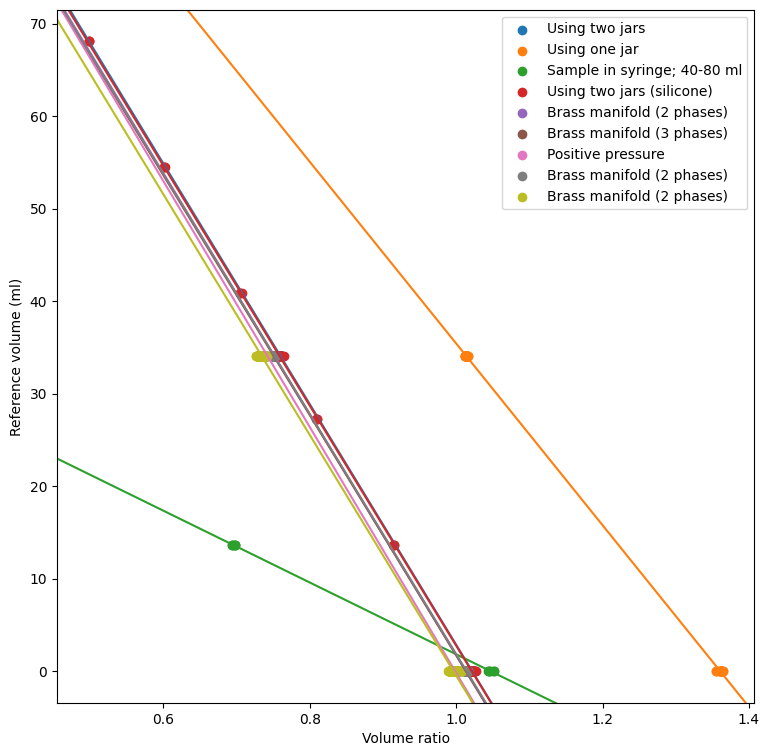

In [25]:
# Create the figure
fig, ax = plt.subplots(figsize=(9,9))
fig.patch.set_facecolor('white')

for method_id in samples.method_id.unique():
    # Get samples for this method
    samples_this_method = samples_w_vol[samples_w_vol.method_id == method_id]
    
    # Get trials for these samples
    trials_this_method = df[[s in samples_this_method.index for s in trials.sample_id]]

    # Get data for this method
    xs = trials_this_method.vol_ratio
    ys = trials_this_method.volume

    # Plot the data
    ax.scatter(xs, ys, label=methods.loc[method_id].description)

# Get axis limits
xlim = ax.get_xlim()
ylim = ax.get_ylim()

for method_id in samples.method_id.unique():
    # Get the fit for this method
    xs = np.linspace(*xlim)
    ys = volume_func(xs, *vol_fits[method_id][0])
    
    # Plot the fit
    ax.plot(xs, ys)

# Set axis limits
ax.set_xlim(xlim)
ax.set_ylim(ylim)

# Set axis labels
ax.set_xlabel('Volume ratio')
ax.set_ylabel('Reference volume (ml)')

# Draw the legend
plt.legend()

For the remainder of this analysis, we retain only samples for methods 4, 5, 6, and 8, as these produced the most accurate results.

In [26]:
# Keep samples with method 4, 5, 6, 8, 9
samples = samples[[m in [4, 5, 6, 8, 9] for m in samples.method_id]]

# Drop unused trials
trials = trials[[s in samples.index for s in trials.sample_id]]

# Variation in density between brands

Let's start by loading bag, brand, shot and depth information.

In [27]:
bags = pd.read_csv('bags.csv', index_col='id')
bags.tail()

,brand_id
id,
157,109
158,110
159,111
160,112
161,113


In [28]:
brands = pd.read_csv('brands.csv', index_col='id')
brands.tail()

,name
id,
109,Genji Challa
110,Kianyangi AA
111,Irineo Ramirez
112,Humure Station
113,Boa Bedegelo


In [29]:
depths = pd.read_csv('depths.csv', index_col='id')
depths.tail()

,bag_id,grinder_cal_id,basket_id,tamp_force_kg,grind_setting,weight_in_basket,depth_below_rim
id,,,,,,,
1483,161.0,14,5,15.17,4.4,17.99,13.00
1485,161.0,14,5,15.34,4.8,18.01,12.61
1486,161.0,14,5,15.48,4.8,18.00,12.51
1487,161.0,14,5,15.44,2.8,17.99,13.79
1488,161.0,14,5,15.48,2.8,17.99,13.97


In [30]:
baskets = pd.read_csv('baskets.csv', index_col='id')
baskets.tail()

,diameter,depth,volume,description
id,,,,
2,59.00,28.30,74.983333,Double basket that came with naked portafilter
4,58.65,23.35,61.450000,VST 18 g basket
5,58.74,25.26,66.903333,VST 20 g basket


Now we can calculate the volume and density of each trial using the linear fits calculated above.

In [31]:
def get_volume_and_density(row):
    sample = samples.loc[row.sample_id]
    vol_calc = volume_func(row.vol_ratio, *vol_fits[sample.method_id][0])
    density = sample.weight / vol_calc
    return pd.Series([vol_calc, density], index=['volume', 'density'])

trials[['volume', 'density']] = trials.apply(get_volume_and_density, axis = 1)
trials.tail()

,sample_id,filename,vol_ratio,sigma_vol_ratio,volume,density
id,,,,,,
3151,1052,trials/trial-3151.csv,0.993179,0.000524,0.416621,0.000000
3152,1052,trials/trial-3152.csv,0.994572,0.000525,0.235463,0.000000
3153,1053,trials/trial-3153.csv,0.734052,0.000397,34.115254,7.895588
3154,1053,trials/trial-3154.csv,0.734174,0.000400,34.099348,7.899271
3155,1053,trials/trial-3155.csv,0.735314,0.000400,33.951136,7.933755


Let's create a list of bags sorted by bean density.

In [32]:
# Shortened labels
short_labels = {52: 'Tamana Varietales', 
                53: 'Tamana Caturron'}

# Initialize the list
bag_info = []

# Get unique bags
samples_w_bag = samples.dropna(subset='bag_id')

# Get bag ids
bag_ids = samples_w_bag.bag_id.unique()
bags_used = bags[[i in bag_ids for i in bags.index]]

# Sort bag_ids by bean density
for bag_id in bag_ids:
    # Get brand
    brand_id = bags.loc[bag_id].brand_id

    # Get label
    if brand_id in short_labels:
        bag_label = short_labels[brand_id]
    else:
        bag_label = brands.loc[brand_id]['name']

    # Handle brands with more than one bag
    if len(bags_used[bags_used.brand_id == brand_id]) > 1:
        bag_label += f' #{bag_id:.0f}'
    
    # Get samples for this bag
    samples_this_bag = samples[samples.bag_id == bag_id]

    # Separate into beans and ground coffee
    has_grind_setting = ~samples_this_bag.grind_setting.isna()

    # Get bean trials
    bean_samples = samples_this_bag[~has_grind_setting]
    bean_trials = trials[[s in bean_samples.index for s in trials.sample_id]]

    if not bean_trials.empty:
        # Get average bean density
        density = bean_trials.density.mean()

        # Add to list
        bag_info.append((bag_id, bag_label, density))

# Sort the list by density
bag_info = sorted(bag_info, key=lambda x: x[2])

Now let's plot density for beans, ground coffee, and tamped coffee with a grind setting of 2.00.

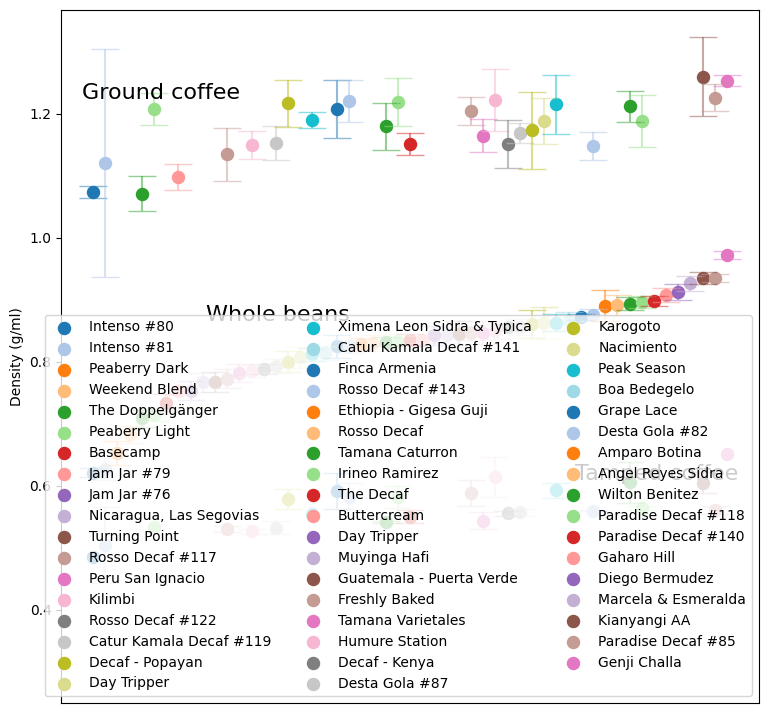

In [33]:
def get_volume(row):
    basket = baskets.loc[row.basket_id]
    return basket.volume - np.pi * (basket.diameter / 2)**2 * row.depth_below_rim / 1000
    
# Get color map
bag_colors = plt.colormaps['tab20'].colors + plt.colormaps['tab20'].colors + plt.colormaps['tab20'].colors

# Create the figure
fig, ax = plt.subplots(figsize=(9,9))
fig.patch.set_facecolor('white')

for i, (bag_id, label, _) in enumerate(bag_info):
    # Get samples for this bag
    samples_this_bag = samples[samples.bag_id == bag_id]

    # Separate into beans and ground coffee
    has_grind_setting = ~samples_this_bag.grind_setting.isna()

    # Get bean trials
    bean_samples = samples_this_bag[~has_grind_setting]
    bean_trials = trials[[s in bean_samples.index for s in trials.sample_id]]

    if not bean_trials.empty:
        # Get trial densities
        densities = bean_trials.density

        # Calculate mean and standard deviation
        ys = densities.mean()
        yerrs = densities.std() * 1.96

        # Plot
        if len(densities) > 1:
            ax.errorbar(i, ys, yerr=yerrs, fmt='none', capsize=10, color=bag_colors[i], alpha=0.5)
        ax.scatter(i, ys, color=bag_colors[i], label=label, s=75)
        
    # Get ground trials
    ground_samples = samples_this_bag[has_grind_setting & (samples_this_bag.grind_setting == 2.00)]
    ground_trials = trials[[s in ground_samples.index for s in trials.sample_id]]

    if not ground_trials.empty:
        # Get trial densities
        densities = ground_trials.density

        # Calculate mean and standard deviation
        ys = densities.mean()
        yerrs = densities.std() * 1.96

        # Plot
        if len(densities) > 1:
            ax.errorbar(i, ys, yerr=yerrs, fmt='none', capsize=10, color=bag_colors[i], alpha=0.5)
        ax.scatter(i, ys, color=bag_colors[i], s=75)

    # Get tamped densities
    depths_this_bag = depths[(depths.bag_id == bag_id) & (depths.grind_setting == 2.00)]

    if not depths_this_bag.empty:
        # Calculate densities
        volumes = depths_this_bag.apply(get_volume, axis=1)
        densities = depths_this_bag.weight_in_basket / volumes

        # Calculate mean and standard deviation
        ys = densities.mean()
        yerrs = densities.std() * 1.96

        # Plot
        if len(densities) > 1:
            ax.errorbar(i, ys, yerr=yerrs, fmt='none', capsize=10, color=bag_colors[i], alpha=0.5)
        ax.scatter(i, ys, color=bag_colors[i], s=75)

# Add text labels
plt.text(0.03, 0.88, 'Ground coffee', fontsize=16, 
         horizontalalignment='left', verticalalignment='center', 
         transform=ax.transAxes)

plt.text(0.31, 0.56, 'Whole beans', fontsize=16, 
         horizontalalignment='center', verticalalignment='center', 
         transform=ax.transAxes)

plt.text(0.97, 0.33, 'Tamped coffee', fontsize=16, 
         horizontalalignment='right', verticalalignment='center', 
         transform=ax.transAxes)

# Set y limits
ylim = plt.ylim()
plt.ylim(ylim[0] - 0.15, ylim[1])

# Set ticks and labels
ax.set_xticks([])
ax.set_xticklabels([])

# Set axis labels
ax.set_ylabel('Density (g/ml)')

# Draw legend
plt.legend(loc='lower right', ncol=3)

What if we look at the density of ground coffee relative to the whole beans?

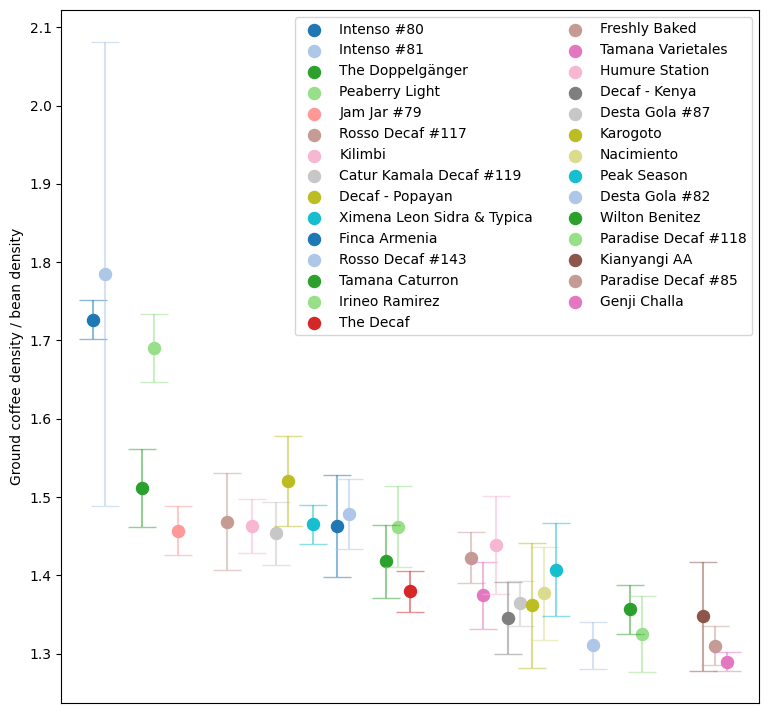

In [34]:
# Create the figure
fig, ax = plt.subplots(figsize=(9,9))
fig.patch.set_facecolor('white')

for i, (bag_id, label, _) in enumerate(bag_info):
    # Get samples for this bag
    samples_this_bag = samples[samples.bag_id == bag_id]

    # Separate into beans and ground coffee
    has_grind_setting = ~samples_this_bag.grind_setting.isna()

    # Get bean trials
    bean_samples = samples_this_bag[~has_grind_setting]
    bean_trials = trials[[s in bean_samples.index for s in trials.sample_id]]

    # Get ground trials
    ground_samples = samples_this_bag[has_grind_setting & (samples_this_bag.grind_setting == 2.00)]
    ground_trials = trials[[s in ground_samples.index for s in trials.sample_id]]

    if not bean_trials.empty and not ground_trials.empty:
        # Get bean densities
        bean_densities = bean_trials.density

        # Get ground densities
        ground_densities = ground_trials.density

        # Calculate mean and standard deviation
        ys = ground_densities.mean() / bean_densities.mean()
        yerrs = np.sqrt((ground_densities.std() / bean_densities.mean())**2 + 
                        (ground_densities.mean() / bean_densities.mean()**2 * bean_densities.std())**2) * 1.96

        # Plot
        if len(bean_densities) > 1 and len(ground_densities) > 1:
            ax.errorbar(i, ys, yerr=yerrs, fmt='none', capsize=10, color=bag_colors[i], alpha=0.5)
        ax.scatter(i, ys, color=bag_colors[i], label=label, s=75)

# Set ticks and labels
ax.set_xticks([])
ax.set_xticklabels([])

# Set axis labels
ax.set_ylabel('Ground coffee density / bean density')

# Draw legend
plt.legend(loc='upper right', ncol=2)

How about the density of the tamped puck vs. the ground coffee?

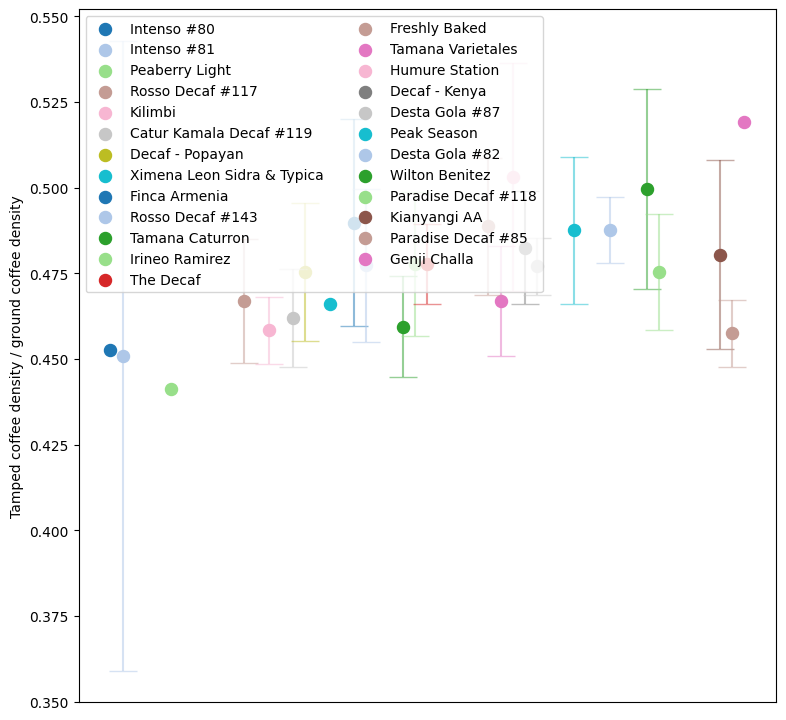

In [35]:
# Create the figure
fig, ax = plt.subplots(figsize=(9,9))
fig.patch.set_facecolor('white')

for i, (bag_id, label, _) in enumerate(bag_info):
    # Get samples for this bag
    samples_this_bag = samples[samples.bag_id == bag_id]

    # Separate into beans and ground coffee
    has_grind_setting = ~samples_this_bag.grind_setting.isna()

    # Get ground trials
    ground_samples = samples_this_bag[has_grind_setting & (samples_this_bag.grind_setting == 2.00)]
    ground_trials = trials[[s in ground_samples.index for s in trials.sample_id]]

    # Get depth measurements
    depths_this_bag = depths[(depths.bag_id == bag_id) & (depths.grind_setting == 2.00)]

    if not ground_trials.empty and not depths_this_bag.empty:
        # Get ground densities
        ground_densities = ground_trials.density

        # Calculate tamped densities
        volumes = depths_this_bag.apply(get_volume, axis=1)
        tamped_densities = depths_this_bag.weight_in_basket / volumes
        
        # Calculate mean and standard deviation
        ys = tamped_densities.mean() / ground_densities.mean()
        yerrs = np.sqrt((tamped_densities.std() / ground_densities.mean())**2 + 
                        (tamped_densities.mean() / ground_densities.mean()**2 * ground_densities.std())**2) * 1.96

        # Plot
        if len(ground_densities) > 1 and len(tamped_densities) > 1:
            ax.errorbar(i, ys, yerr=yerrs, fmt='none', capsize=10, color=bag_colors[i], alpha=0.5)
        ax.scatter(i, ys, color=bag_colors[i], label=label, s=75)

# Set ticks and labels
ax.set_xticks([])
ax.set_xticklabels([])

# Set axis labels
ax.set_ylabel('Tamped coffee density / ground coffee density')

# Draw legend
plt.legend(loc='upper left', ncol=2)

# Variation in ground coffee density with grind setting

Above, we saw that the density of ground coffee relative to the density of the whole beans changes depending on the coffee. This measurement also changes within a single coffee, as grind setting changes. Rather than look at this change in terms of grind setting, in the analysis below I will convert to burr spacing using measurements made on my Specialita grinder. First, let's import those measurements.

In [36]:
grinder_cals = pd.read_csv('grinder_cals.csv', index_col='id')
grinder_cals.tail()

,date,grinder_id,zero_digits,um_per_digit,burr_angle,notes
id,,,,,,
4,NaN,1,0.1,47.0,0.0,Re-aligned grinder; https://quantitativecafe.c...
13,2024-06-23,3,-1.6,30.0,0.0,Used 5.0 in-lb torque on screws; cleaned pushi...
14,2024-08-11,3,-1.6,30.0,0.0,Used 5.0 in-lb torque on screws; cleaned and l...
15,2024-11-08,4,0.3,80.0,66.0,Touch point has drifted; actual burr touch at ...


Now let's calculate burr spacing from grind setting.

In [37]:
def get_burr_spacing(row):
    if not np.isnan(row.grinder_cal_id):
        grinder_cal = grinder_cals.loc[row.grinder_cal_id]
        burr_spacing = (row.grind_setting - grinder_cal.zero_digits) * grinder_cal.um_per_digit * np.cos(grinder_cal.burr_angle / 180 * np.pi)
    else:
        burr_spacing = np.nan
    return pd.Series([burr_spacing], index=['burr_spacing'])

samples['burr_spacing'] = samples.apply(get_burr_spacing, axis = 1)
samples.tail()

,date,weight,volume,bag_id,grinder_cal_id,grind_setting,shot_id,depth_id,method_id,description,notes,burr_spacing
id,,,,,,,,,,,,
1049,2025-03-09,269.25,34.05,NaN,NaN,NaN,NaN,NaN,9,75 balls (old),NaN,NaN
1050,2025-03-10,18.11,NaN,161.0,14.0,2.8,2013.0,1487.0,9,Boa Bedegelo (2.80) ground,NaN,132.0
1051,2025-03-10,18.10,NaN,161.0,14.0,2.8,2014.0,1488.0,9,Boa Bedegelo (2.80) ground,NaN,132.0
1052,2025-03-10,0.00,0.00,NaN,NaN,NaN,NaN,NaN,9,Empty,NaN,NaN
1053,2025-03-10,269.36,34.05,NaN,NaN,NaN,NaN,NaN,9,75 balls (old),NaN,NaN


Text(0, 0.5, 'Density (g/ml)')

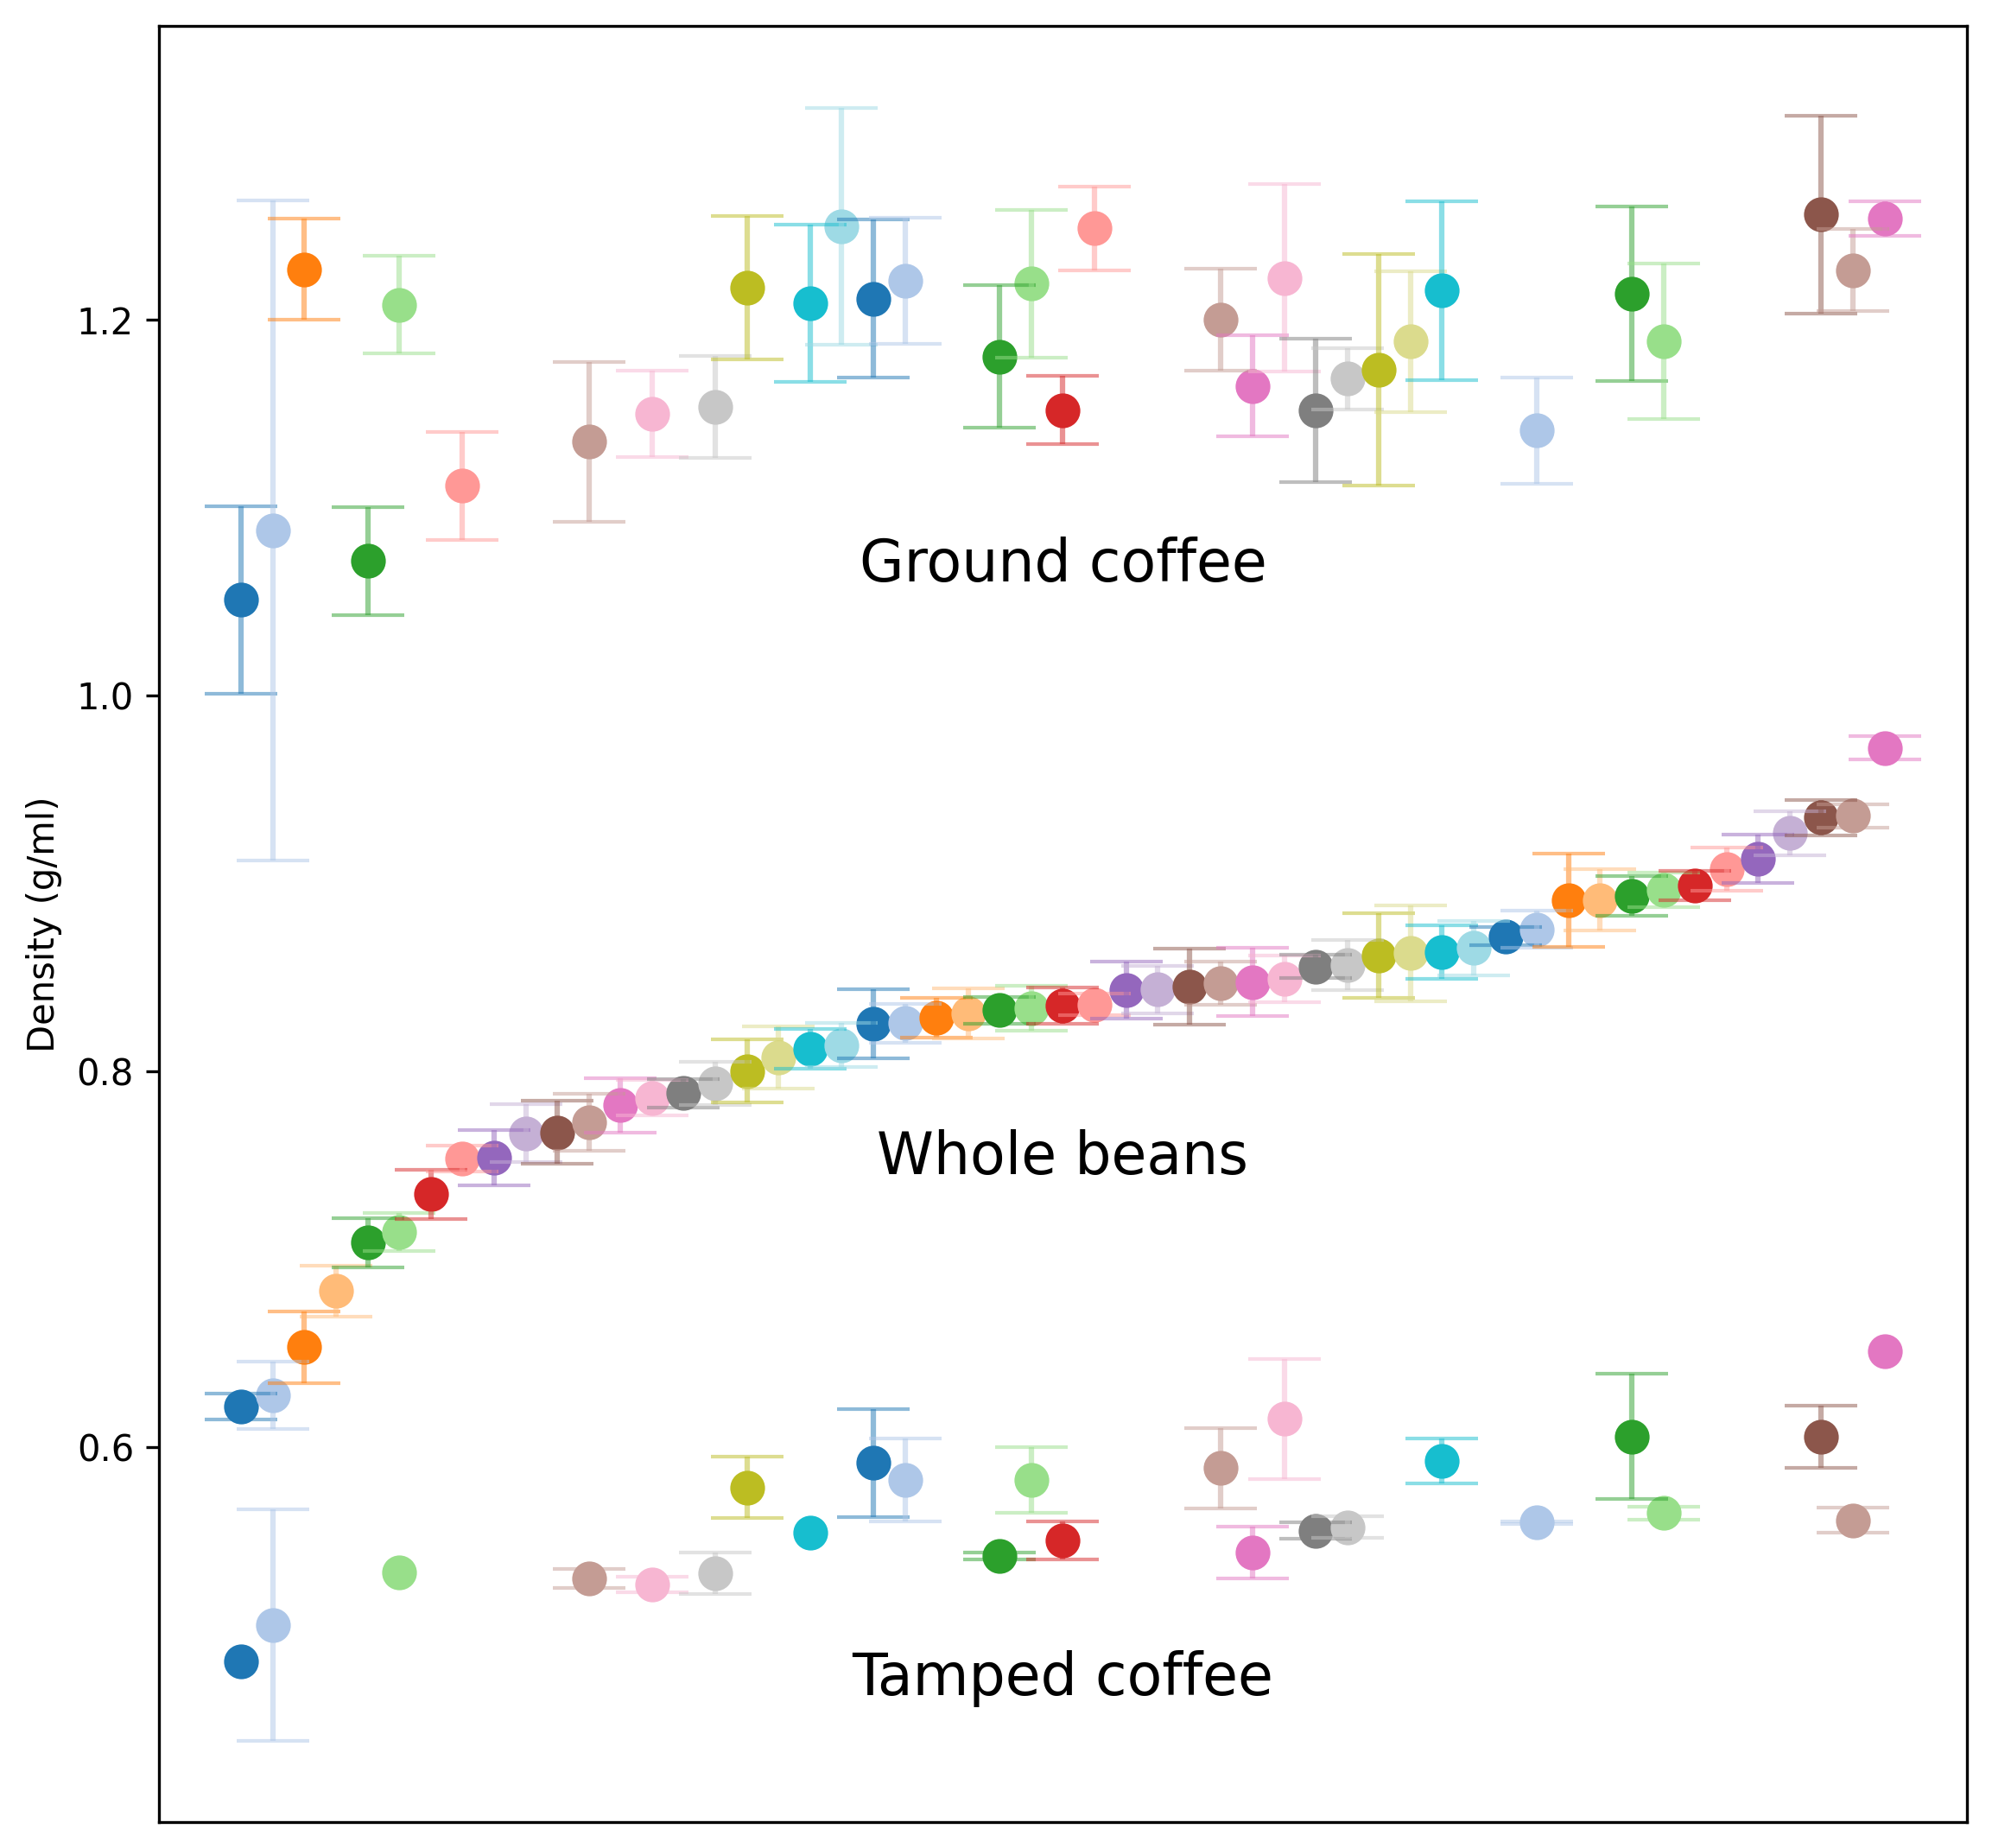

In [38]:
def get_volume(row):
    basket = baskets.loc[row.basket_id]
    return basket.volume - np.pi * (basket.diameter / 2)**2 * row.depth_below_rim / 1000
    
# Get color map
bag_colors = plt.colormaps['tab20'].colors + plt.colormaps['tab20'].colors + plt.colormaps['tab20'].colors

# Create the figure
fig, ax = plt.subplots(figsize=(9,9), dpi=300)
fig.patch.set_facecolor('none')

for i, (bag_id, label, _) in enumerate(bag_info):
    # Get samples for this bag
    samples_this_bag = samples[samples.bag_id == bag_id]

    # Separate into beans and ground coffee
    has_grind_setting = ~samples_this_bag.grind_setting.isna()

    # Get bean trials
    bean_samples = samples_this_bag[~has_grind_setting]
    bean_trials = trials[[s in bean_samples.index for s in trials.sample_id]]

    if not bean_trials.empty:
        # Get trial densities
        densities = bean_trials.density

        # Calculate mean and standard deviation
        ys = densities.mean()
        yerrs = densities.std() * 1.96

        # Plot
        if len(densities) > 1:
            ax.errorbar(i, ys, yerr=yerrs, fmt='none', capsize=10, color=bag_colors[i], alpha=0.5)
        ax.scatter(i, ys, color=bag_colors[i], label=label, s=75)
        
    # Get ground trials
    ground_samples = samples_this_bag[
        has_grind_setting & 
        (samples_this_bag.burr_spacing > 80) & 
        (samples_this_bag.burr_spacing < 120)]
    ground_trials = trials[[s in ground_samples.index for s in trials.sample_id]]

    if not ground_trials.empty:
        # Get trial densities
        densities = ground_trials.density

        # Calculate mean and standard deviation
        ys = densities.mean()
        yerrs = densities.std() * 1.96

        # Plot
        if len(densities) > 1:
            ax.errorbar(i, ys, yerr=yerrs, fmt='none', capsize=10, color=bag_colors[i], alpha=0.5)
        ax.scatter(i, ys, color=bag_colors[i], s=75)

    # Get tamped densities
    depths_this_bag = depths[(depths.bag_id == bag_id) & (depths.grind_setting == 2.00)]

    if not depths_this_bag.empty:
        # Calculate densities
        volumes = depths_this_bag.apply(get_volume, axis=1)
        densities = depths_this_bag.weight_in_basket / volumes

        # Calculate mean and standard deviation
        ys = densities.mean()
        yerrs = densities.std() * 1.96

        # Plot
        if len(densities) > 1:
            ax.errorbar(i, ys, yerr=yerrs, fmt='none', capsize=10, color=bag_colors[i], alpha=0.5)
        ax.scatter(i, ys, color=bag_colors[i], s=75)

# Add text labels
plt.text(0.5, 0.70, 'Ground coffee', fontsize=16, 
         horizontalalignment='center', verticalalignment='center', 
         transform=ax.transAxes)

plt.text(0.5, 0.37, 'Whole beans', fontsize=16, 
         horizontalalignment='center', verticalalignment='center', 
         transform=ax.transAxes)

plt.text(0.5, 0.08, 'Tamped coffee', fontsize=16, 
         horizontalalignment='center', verticalalignment='center', 
         transform=ax.transAxes)

# Set ticks and labels
ax.set_xticks([])
ax.set_xticklabels([])

# Set axis labels
ax.set_ylabel('Density (g/ml)')

# Draw legend
# plt.legend(loc='lower right', ncol=3)

Now let's plot normalized ground coffee density vs. burr spacing.

Text(0, 0.5, 'Ground coffee density / bean density')

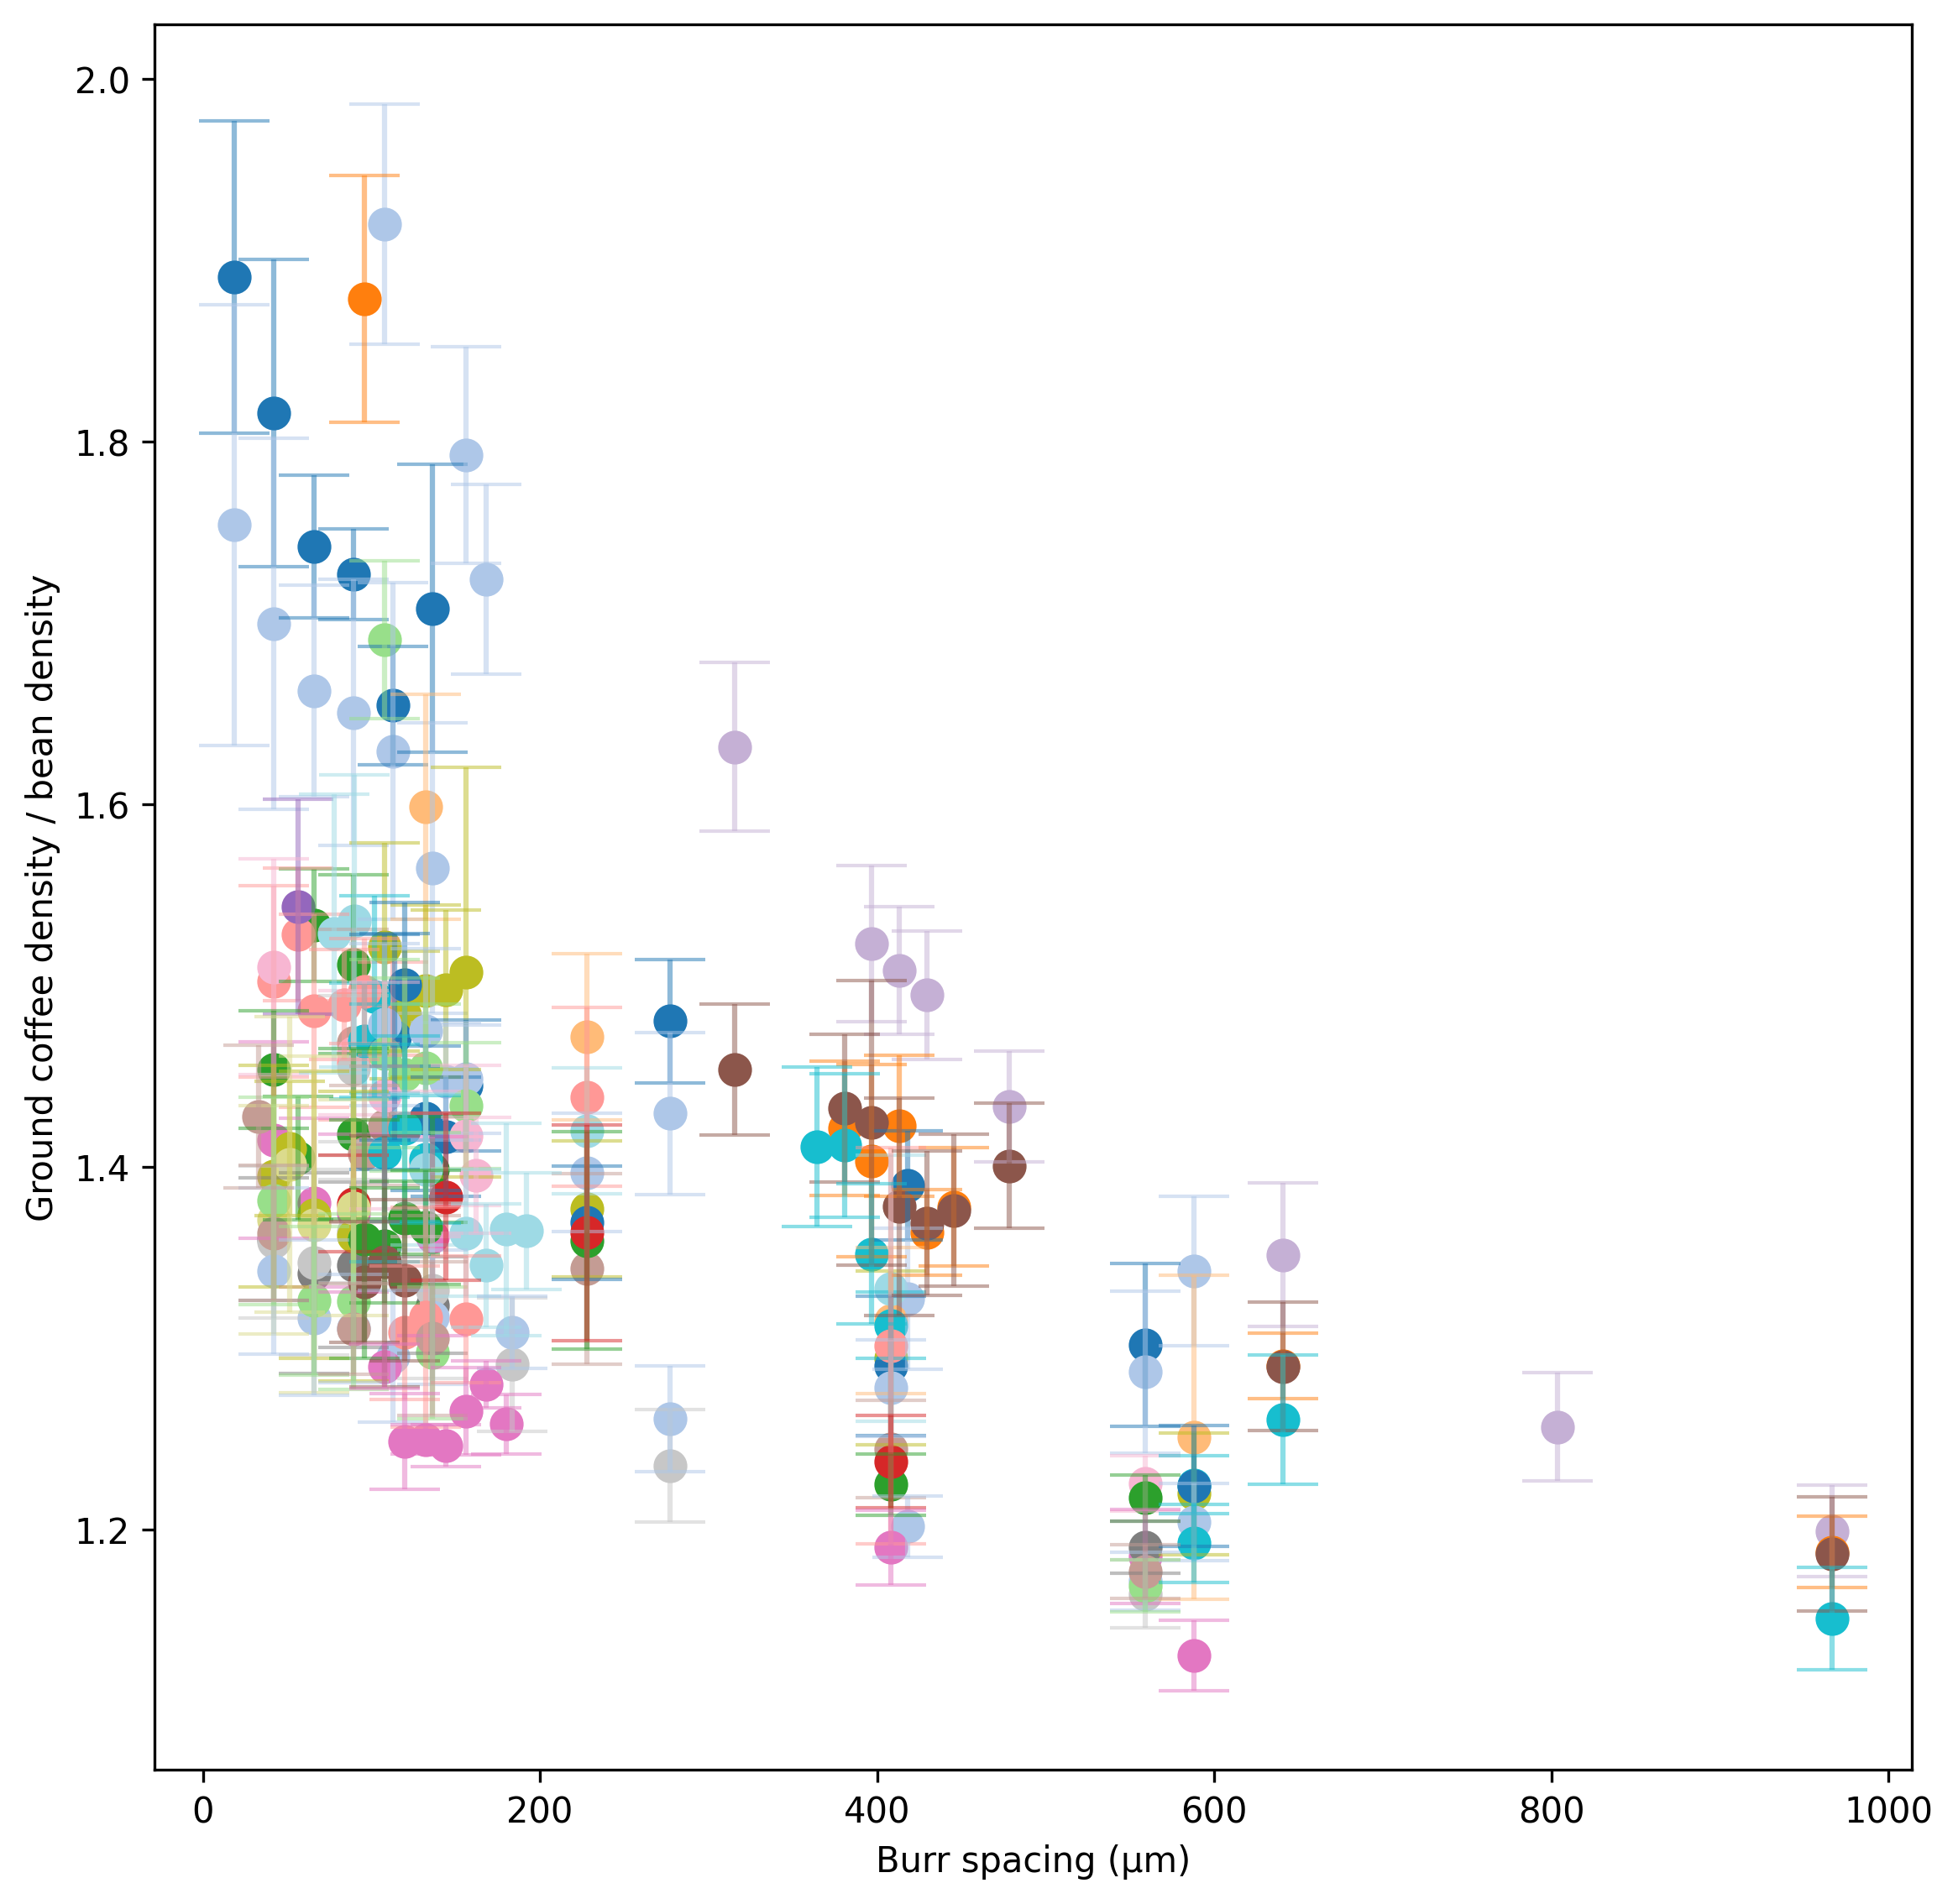

In [39]:
# Create the figure
fig, ax = plt.subplots(figsize=(9,9), dpi=300)
fig.patch.set_facecolor('none')

for i, (bag_id, label, _) in enumerate(bag_info):
    # Get samples for this bag
    samples_this_bag = samples[samples.bag_id == bag_id]
    
    # Separate into beans and ground coffee
    has_grind_setting = ~samples_this_bag.grind_setting.isna()
    
    # Get bean trials
    bean_samples = samples_this_bag[~has_grind_setting]
    bean_trials = trials[[s in bean_samples.index for s in trials.sample_id]]
    
    # Get ground trials
    ground_samples = samples_this_bag[has_grind_setting]
    ground_trials = trials[[s in ground_samples.index for s in trials.sample_id]]

    if not bean_trials.empty:
        # Get bean densities
        bean_densities_mean = bean_trials.density.mean()
        bean_densities_std = bean_trials.density.std()
        
        for burr_spacing in ground_samples.burr_spacing.unique():
            # Get samples for this grind setting
            samples_this_grind = samples_this_bag[samples_this_bag.burr_spacing == burr_spacing]
            trials_this_grind = trials[[s in samples_this_grind.index for s in trials.sample_id]]
        
            if not trials_this_grind.empty:
                # Get ground densities
                ground_densities = trials_this_grind.density
        
                # Calculate mean and standard deviation
                ys = ground_densities.mean() / bean_densities_mean
                yerrs = np.sqrt((ground_densities.std() / bean_densities_mean)**2 + 
                                (ground_densities.mean() / bean_densities_mean**2 * bean_densities_std)**2) * 1.96
        
                # Plot
                if len(ground_densities) > 1:
                    ax.errorbar(burr_spacing, ys, yerr=yerrs, fmt='none', capsize=10, color=bag_colors[i], alpha=0.5)
                ax.scatter(burr_spacing, ys, color=bag_colors[i], label=label, s=75)
        
                # Reset label
                label = None

# Get plot limits
xlim = ax.set_xlim()
ylim = ax.get_ylim()

# Set axis labels
ax.set_xlabel('Burr spacing (µm)')
ax.set_ylabel('Ground coffee density / bean density')

# Draw legend
# plt.legend(loc='upper right', ncol=2)

Both of these effects can be explained if we consider what happens when we cut a porous particle. When we do this, we expose some pores which were previously on the inside of the particle. This causes a loss of particle volume, as some pore space which was previously considered inside the particle is now considered part of the space between particles.

The amount of volume lost will be proportional to the total surface area of the cut particles. For very large particles with little surface area (like a bean), we will have a relatively small loss of volume, but as the particle size gets smaller an the surface area gets larger, this number will increase.

We can model this as:

$$
\rho = \frac{m}{V_0 - \Delta V} = \frac{1}{1 / \rho_0 - \Delta V / m} = \frac{1}{1 / \rho_0 - a S}
$$

Here, $\rho_0$ is the density of the porous material, $a$ is the amount of volume lost per unit of surface area, and $S$ is the specific surface area of the sample. Specific surface area will depend on the size and shape of the constituent particles. For a sample composed of spherical particles, we have:

$$
S = \frac{4 \pi r^2}{\rho_0 \cdot 4/3 \pi r^3} = \frac{3}{\rho_0 r} = \frac{6}{\rho_0 d}
$$

So:

$$
\rho = \frac{1}{1 / \rho_0 - 6 a / \rho_0 d} = \frac{\rho_0}{1 - 6 a / d}
$$

We don't know what grind setting would correspond with zero particle size, so we define this as $d_0$ and get:

$$
\frac{\rho}{\rho_0} = \frac{1}{1 - 6 a / (d - d_0)}
$$

Now, suppose that $d_0$ is a characteristic of the grinder, and $a$ is a characteristic of the bean. Then we can fit the data above to a family of curves of this form as follows.

In [40]:
# Helper functions
def get_burr_spacing(row):
    return samples.loc[row.sample_id].burr_spacing

def get_normalized_density(row):
    bag_id = samples.loc[row.sample_id].bag_id
    sample_ids = samples[(samples.bag_id == bag_id) & (samples.grinder_cal_id.isna())].index
    bean_density = trials[[i in sample_ids for i in trials.sample_id]].density.mean()
    return row.density / bean_density

def get_grinder_id(row):
    grinder_cal_id = samples.loc[row.sample_id].grinder_cal_id
    if ~np.isnan(grinder_cal_id):
        return grinder_cals.loc[grinder_cal_id].grinder_id
    else:
        return np.nan

def get_bag_id(row):
    return samples.loc[row.sample_id].bag_id

# Define the model function
def density_func(burr_spacing, d0, a):
    return 1 / (1 - 2 * a / (burr_spacing - d0))**3

# Define the objective function
def objective(params, burr_spacing, density, grinder_indices, bag_indices, N_d0):
    d0_values = params[:N_d0]
    a_values = params[N_d0:]
    
    # Get the d0 and a for each data point
    d0_s = d0_values[grinder_indices]
    a_s = a_values[bag_indices]
    
    # Calculate the predicted densities
    y_pred = density_func(burr_spacing, d0_s, a_s)
    
    # Compute residuals
    residuals = density - y_pred
    return residuals

# Get trials with ground coffee
ground_sample_ids = samples[(~samples.bag_id.isna()) & (~samples.grinder_cal_id.isna())].index
ground_trials = trials[[i in ground_sample_ids for i in trials.sample_id]]

# Prepare the data
burr_spacing = ground_trials.apply(get_burr_spacing, axis=1).values
density = ground_trials.apply(get_normalized_density, axis=1).values
grinder_ids = ground_trials.apply(get_grinder_id, axis=1).values
bag_ids = ground_trials.apply(get_bag_id, axis=1).values

# Map IDs to indices
unique_grinder_ids = np.unique(grinder_ids)
unique_bag_ids = np.unique(bag_ids)

grinder_id_to_index = {gid: idx for idx, gid in enumerate(unique_grinder_ids)}
bag_id_to_index = {bid: idx for idx, bid in enumerate(unique_bag_ids)}

grinder_indices = np.vectorize(grinder_id_to_index.get)(grinder_ids)
bag_indices = np.vectorize(bag_id_to_index.get)(bag_ids)

# Initial parameter guesses
N_d0 = len(unique_grinder_ids)
N_a = len(unique_bag_ids)

initial_d0 = np.zeros(N_d0)
initial_a = np.ones(N_a) * 1e-3
initial_guess = np.concatenate([initial_d0, initial_a])

# Perform the fitting
result = least_squares(
    objective,
    initial_guess,
    args=(burr_spacing, density, grinder_indices, bag_indices, N_d0)
)

# Extract estimated parameters
d0_estimated = result.x[:N_d0]
a_estimated = result.x[N_d0:]

# Map indices back to IDs for d0
d0_results = {gid: d0_estimated[idx] for gid, idx in grinder_id_to_index.items()}

# Map indices back to IDs for a
a_results = {bid: a_estimated[idx] for bid, idx in bag_id_to_index.items()}

# Print the results
print("Estimated d0 values for each grinder_id:")
for gid, d0 in d0_results.items():
    print(f"grinder_id {gid}: d0 = {d0}")

print("\nEstimated a values for each bag_id:")
for bid, a in a_results.items():
    print(f"bag_id {bid}: a = {a}")

Estimated d0 values for each grinder_id:
grinder_id 1: d0 = -569.208058722885
grinder_id 3: d0 = -421.5027468704721
grinder_id 4: d0 = -182.09631163282108

Estimated a values for each bag_id:
bag_id 52.0: a = 49.04764722136283
bag_id 53.0: a = 42.50635526487215
bag_id 65.0: a = 42.256711655539064
bag_id 76.0: a = 42.12795270721648
bag_id 77.0: a = 31.880420332643432
bag_id 78.0: a = 32.26481989120732
bag_id 79.0: a = 40.175043280683205
bag_id 80.0: a = 54.489666971327566
bag_id 81.0: a = 49.98672096918802
bag_id 82.0: a = 29.016543107945985
bag_id 83.0: a = 33.20492869702992
bag_id 84.0: a = 35.72642446080133
bag_id 85.0: a = 30.20973231089425
bag_id 87.0: a = 30.71751732366018
bag_id 88.0: a = 39.1383769479903
bag_id 117.0: a = 39.584104817612676
bag_id 118.0: a = 29.693813087391945
bag_id 119.0: a = 38.620585060573745
bag_id 120.0: a = 30.41834436901443
bag_id 121.0: a = 33.49092090213857
bag_id 135.0: a = 24.19098410567763
bag_id 136.0: a = 27.018347035162833
bag_id 137.0: a = 33.53

It's interesting that the values of $a$ here are on the order of 30-50 µm. This is approximately the diameter of macropores in roasted coffee (20-40 µm)[1]. This suggests that the "lost volume" may be due to internal pores being exposed by the grinding process, so that they no longer form part of the volume of the particles, but rather part of the volume between particles.

Let's plot these fits. First, for the remaining analyses, we remove any bags for which we do not have a fit.

In [41]:
bag_info_with_fit = [bag for bag in bag_info if bag[0] in np.unique(bag_ids)]

Then we read grinder information.

In [42]:
grinders = pd.read_csv('grinders.csv', index_col='id')
grinders.tail()

,description
id,
1,Eureka Mignon Specialita
3,Timemore Sculptor 078S
4,1Zpresso J-Ultra


Now we can plot.

In [43]:
# precompute arrays once
trial_burr_spacing = trials.apply(get_burr_spacing, axis=1).values
trial_grinder_ids = trials.apply(get_grinder_id, axis=1).values
trial_bag_ids = trials.apply(get_bag_id, axis=1).values

# initialize to infinities
xmin =  np.inf
xmax = -np.inf

for grinder_id in unique_grinder_ids:
    d0 = d0_results[grinder_id]

    for bag_id, *_ in bag_info_with_fit:
        if bag_id not in a_results:
            continue

        # select only the trials for this grinder & bag
        mask = (trial_bag_ids == bag_id) & (trial_grinder_ids == grinder_id)
        bs   = trial_burr_spacing[mask] - d0

        if bs.size:
            xmin = min(xmin, bs.min())
            xmax = max(xmax, bs.max())

# pad by 10%
rng  = xmax - xmin
xmin -= rng * 0.1
xmax += rng * 0.1

print(xmin, xmax)

432.64608376751414 1213.580438473051


Eureka Mignon Specialita


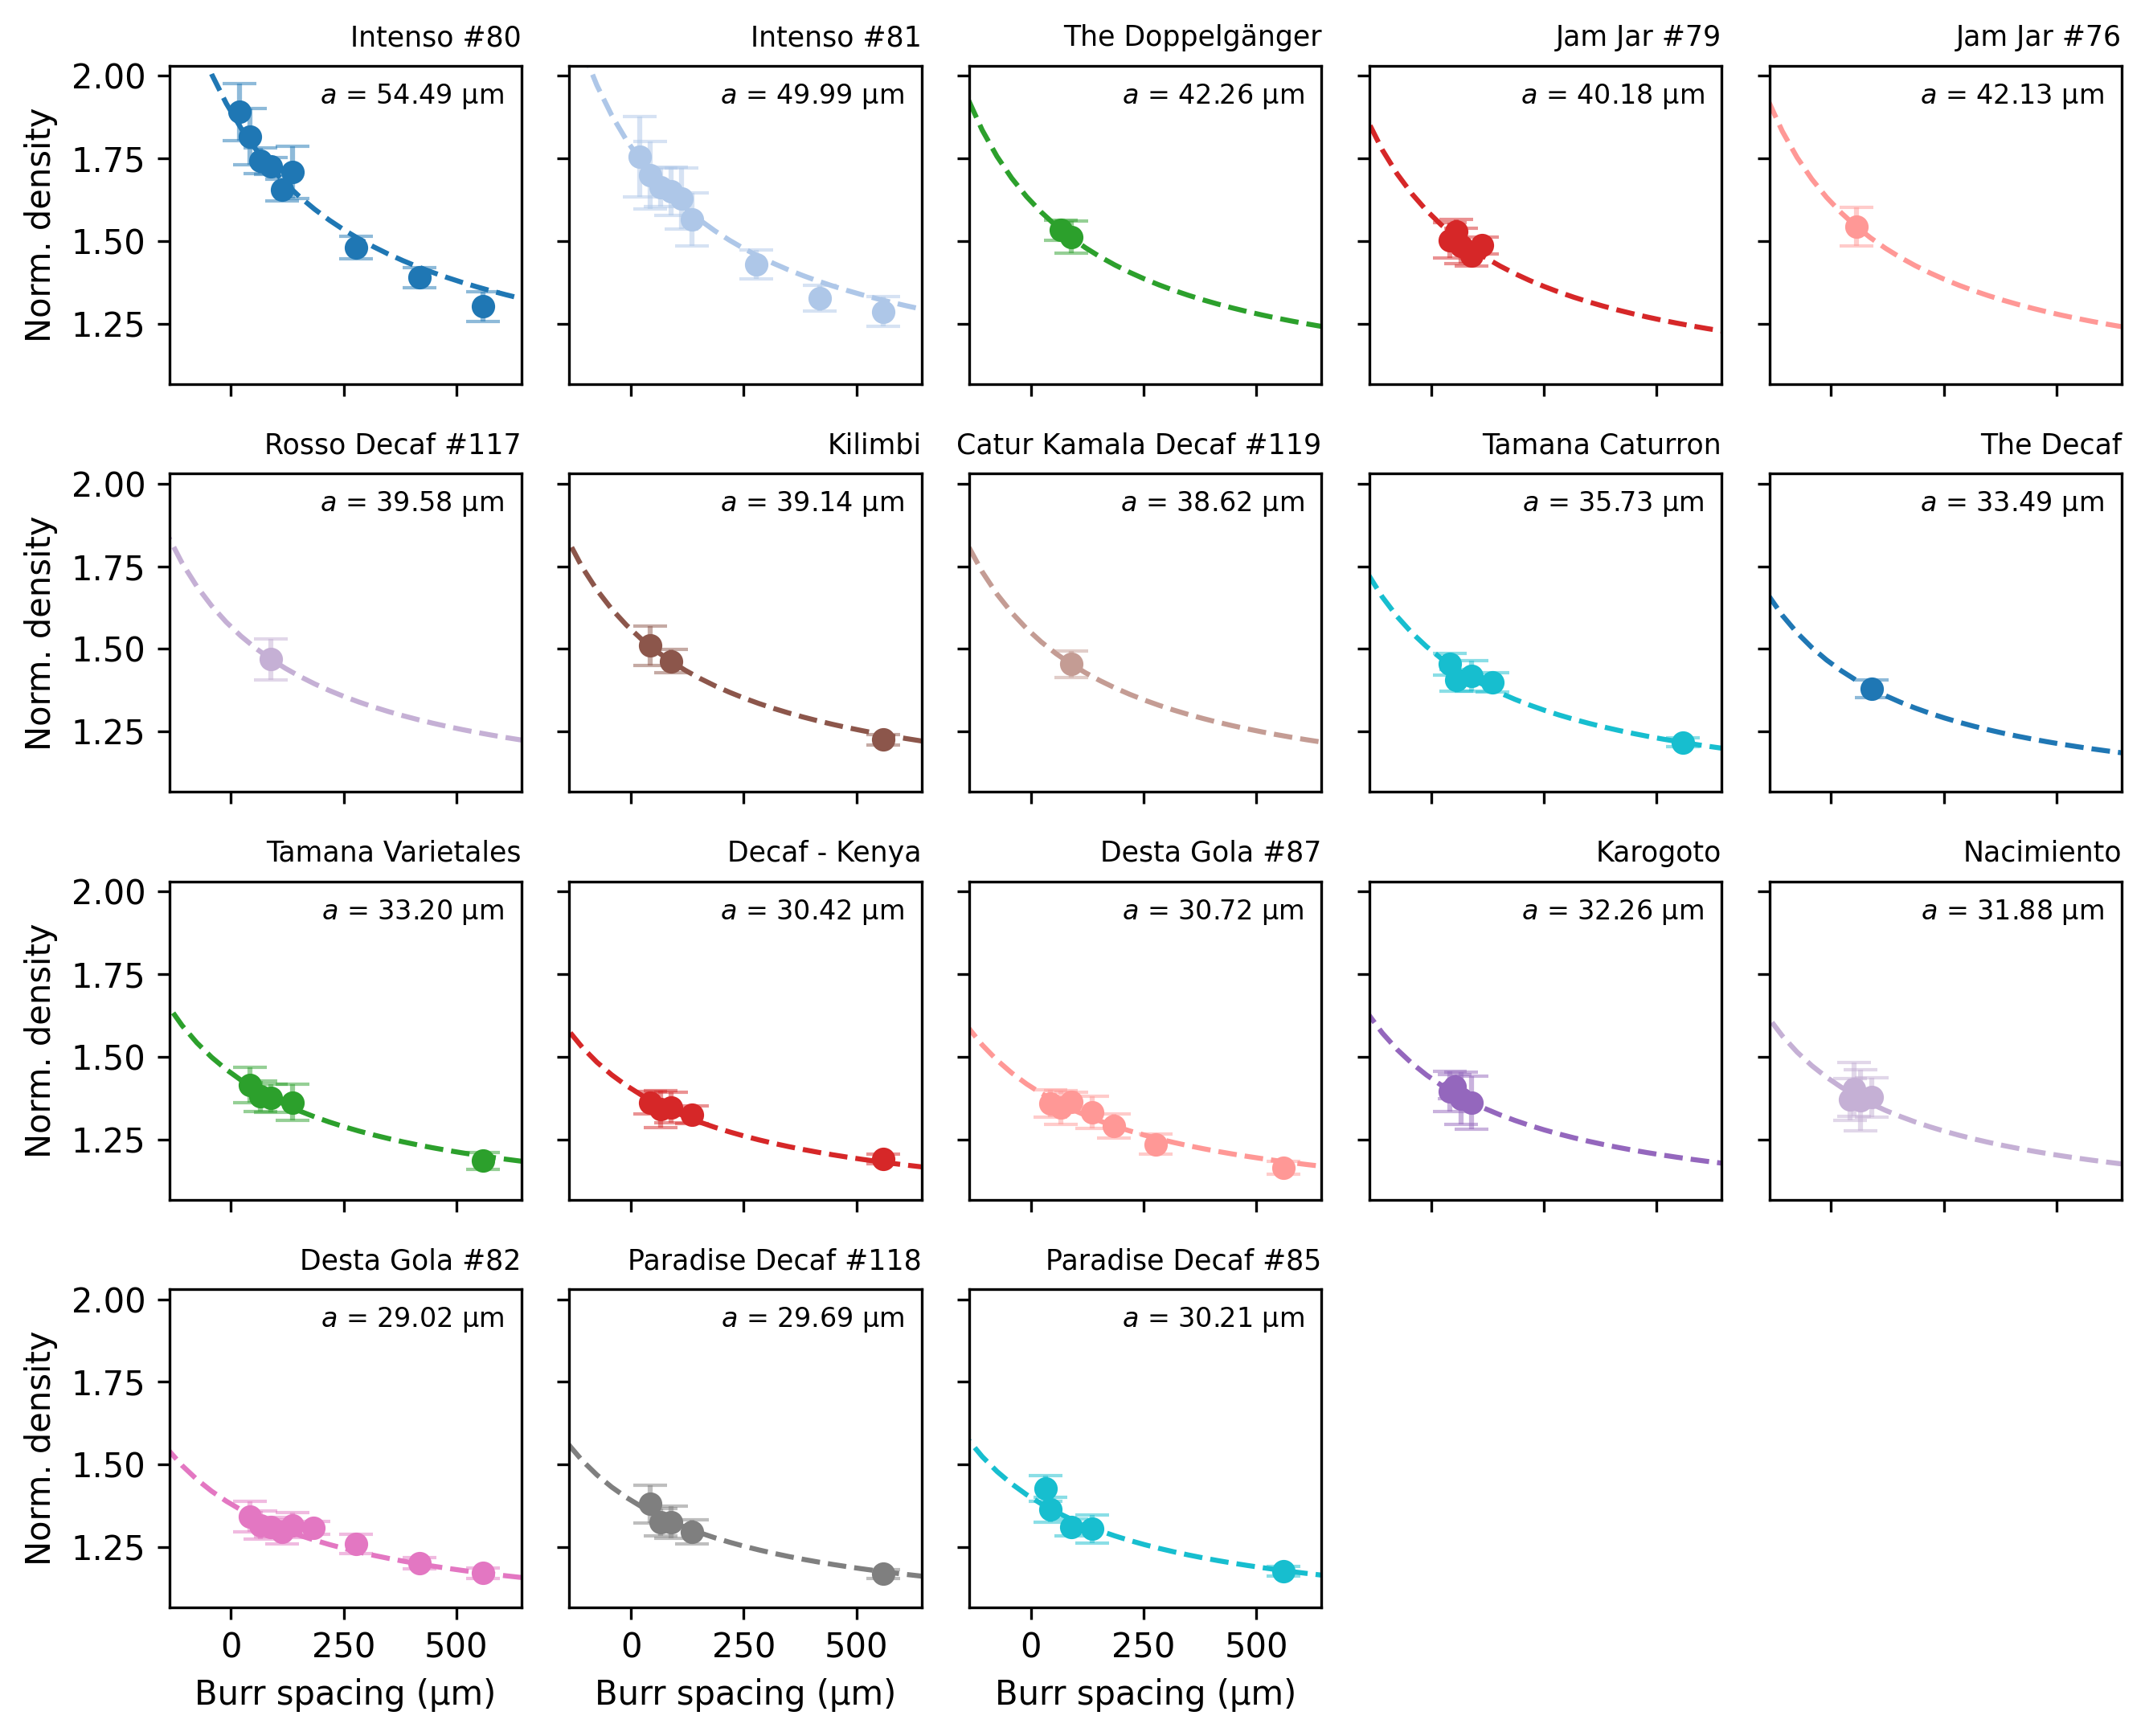

Timemore Sculptor 078S


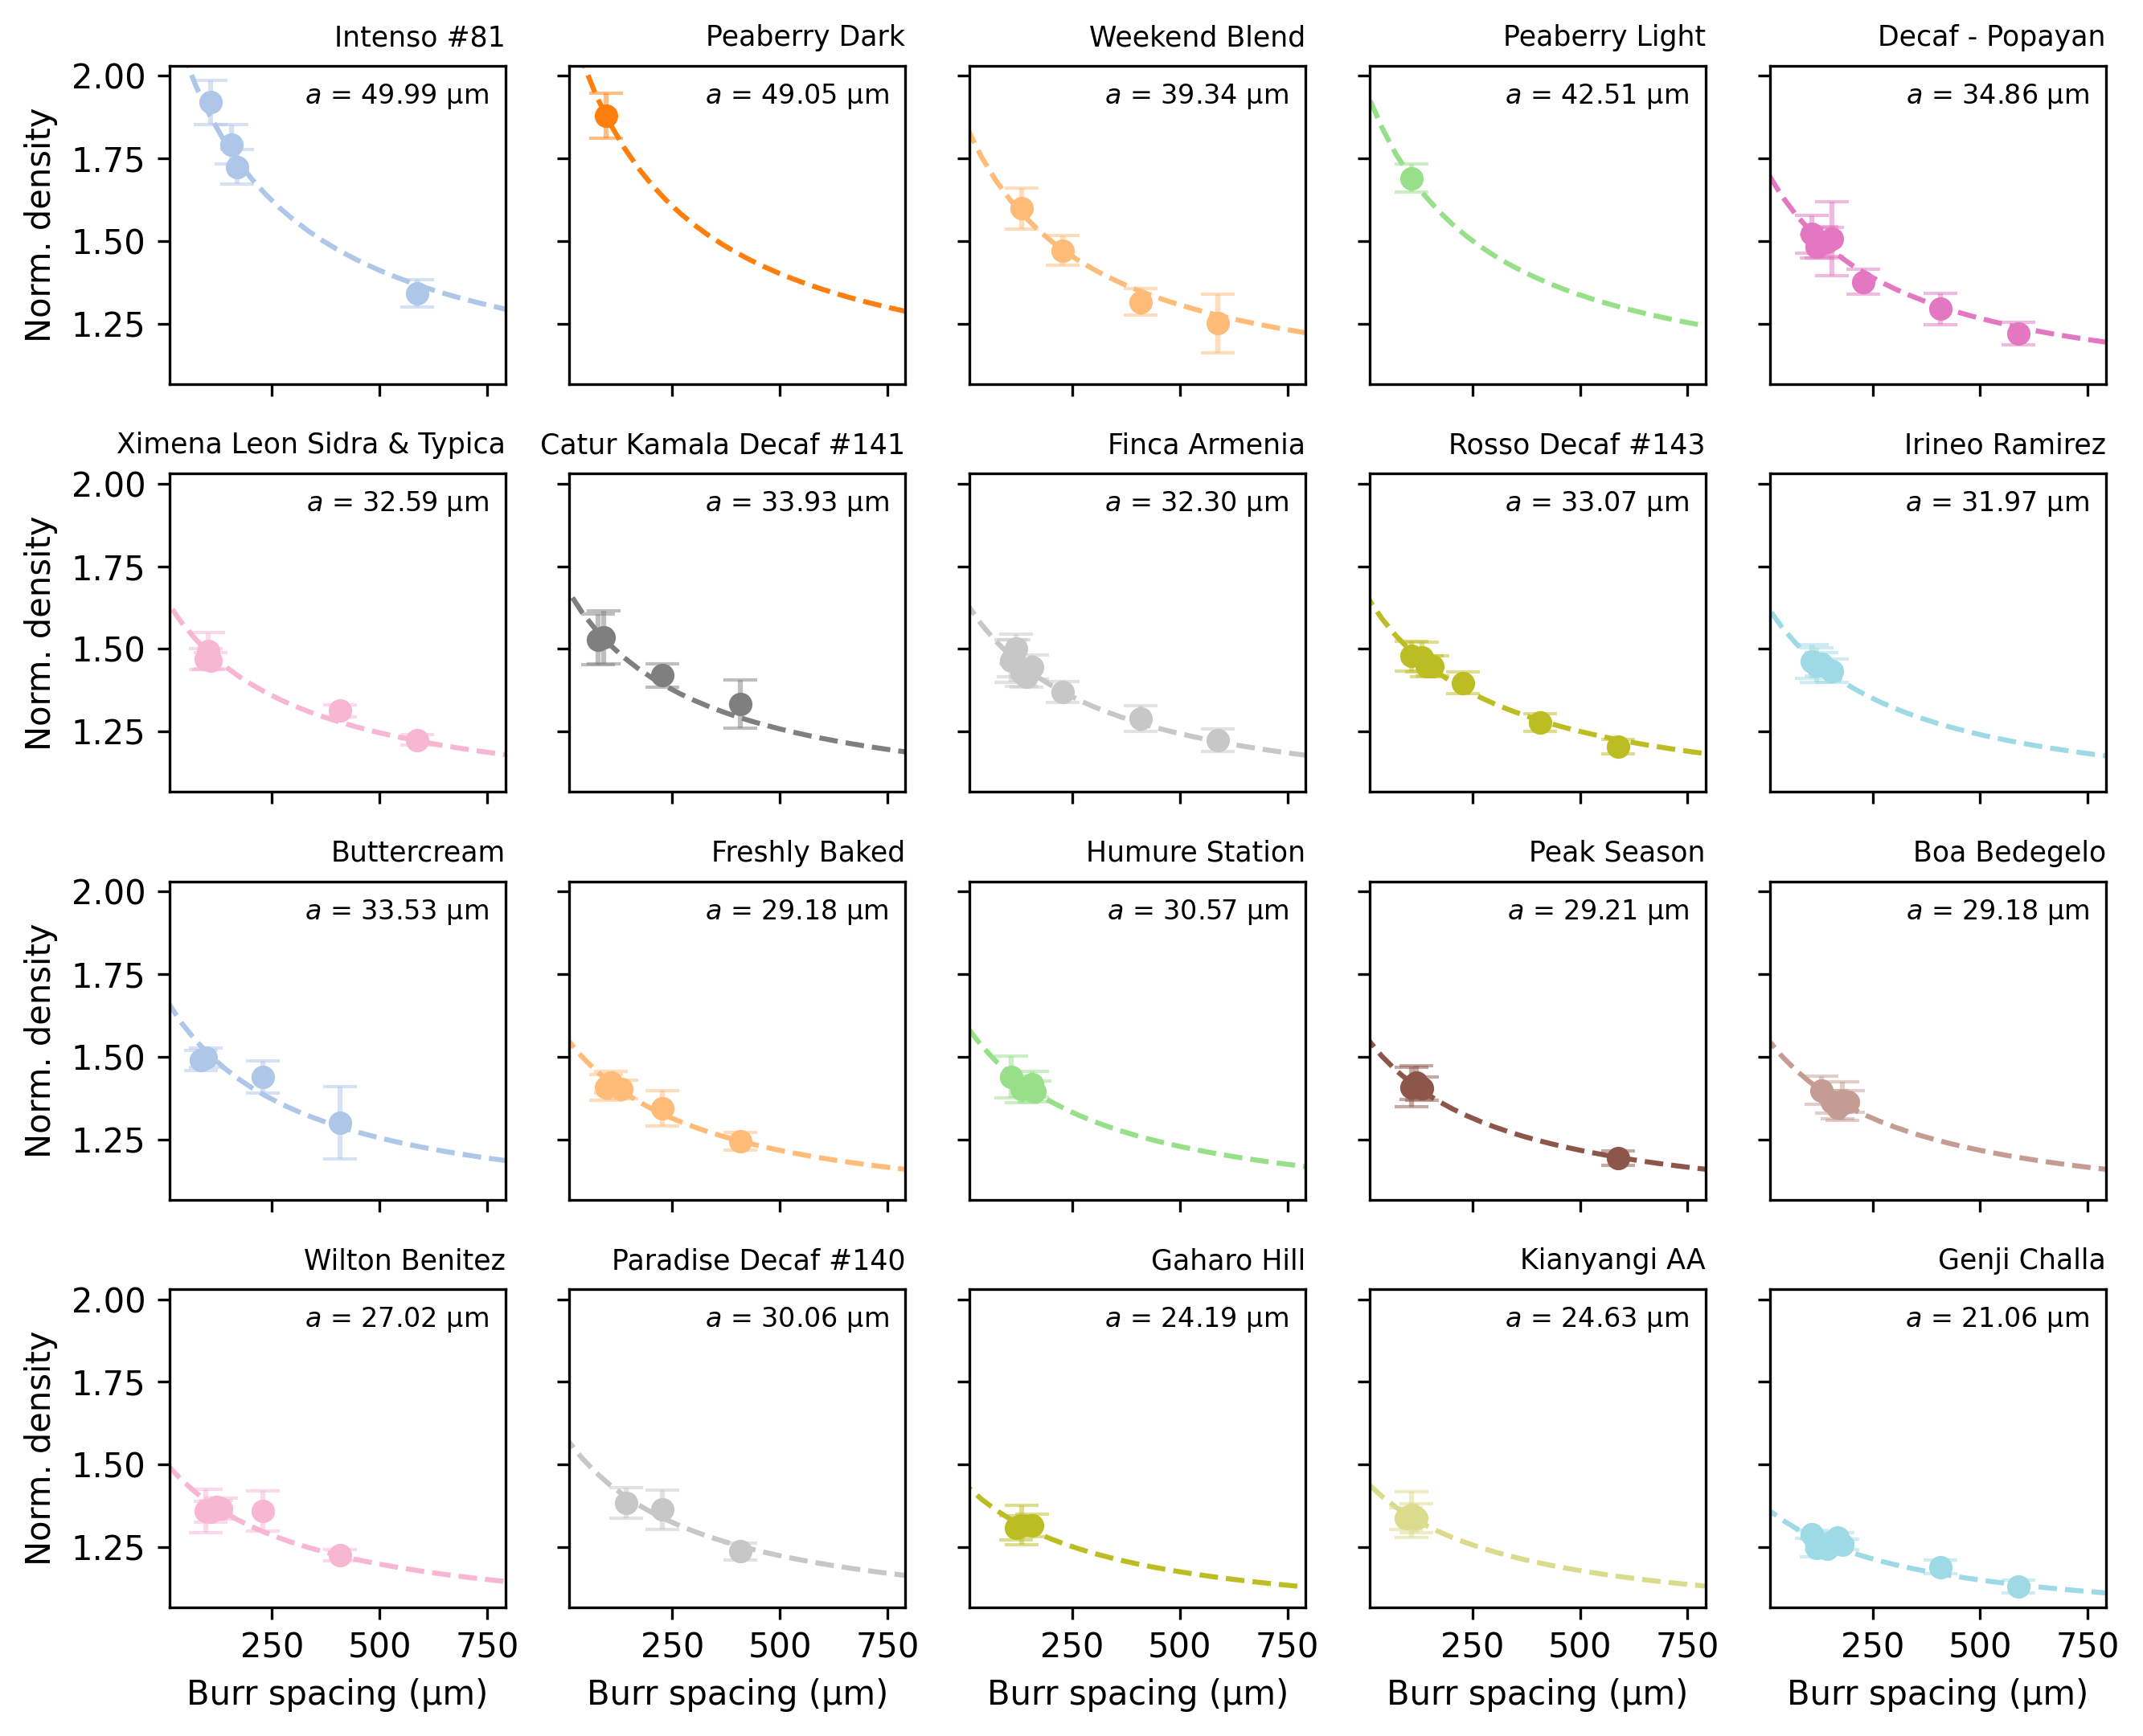

1Zpresso J-Ultra


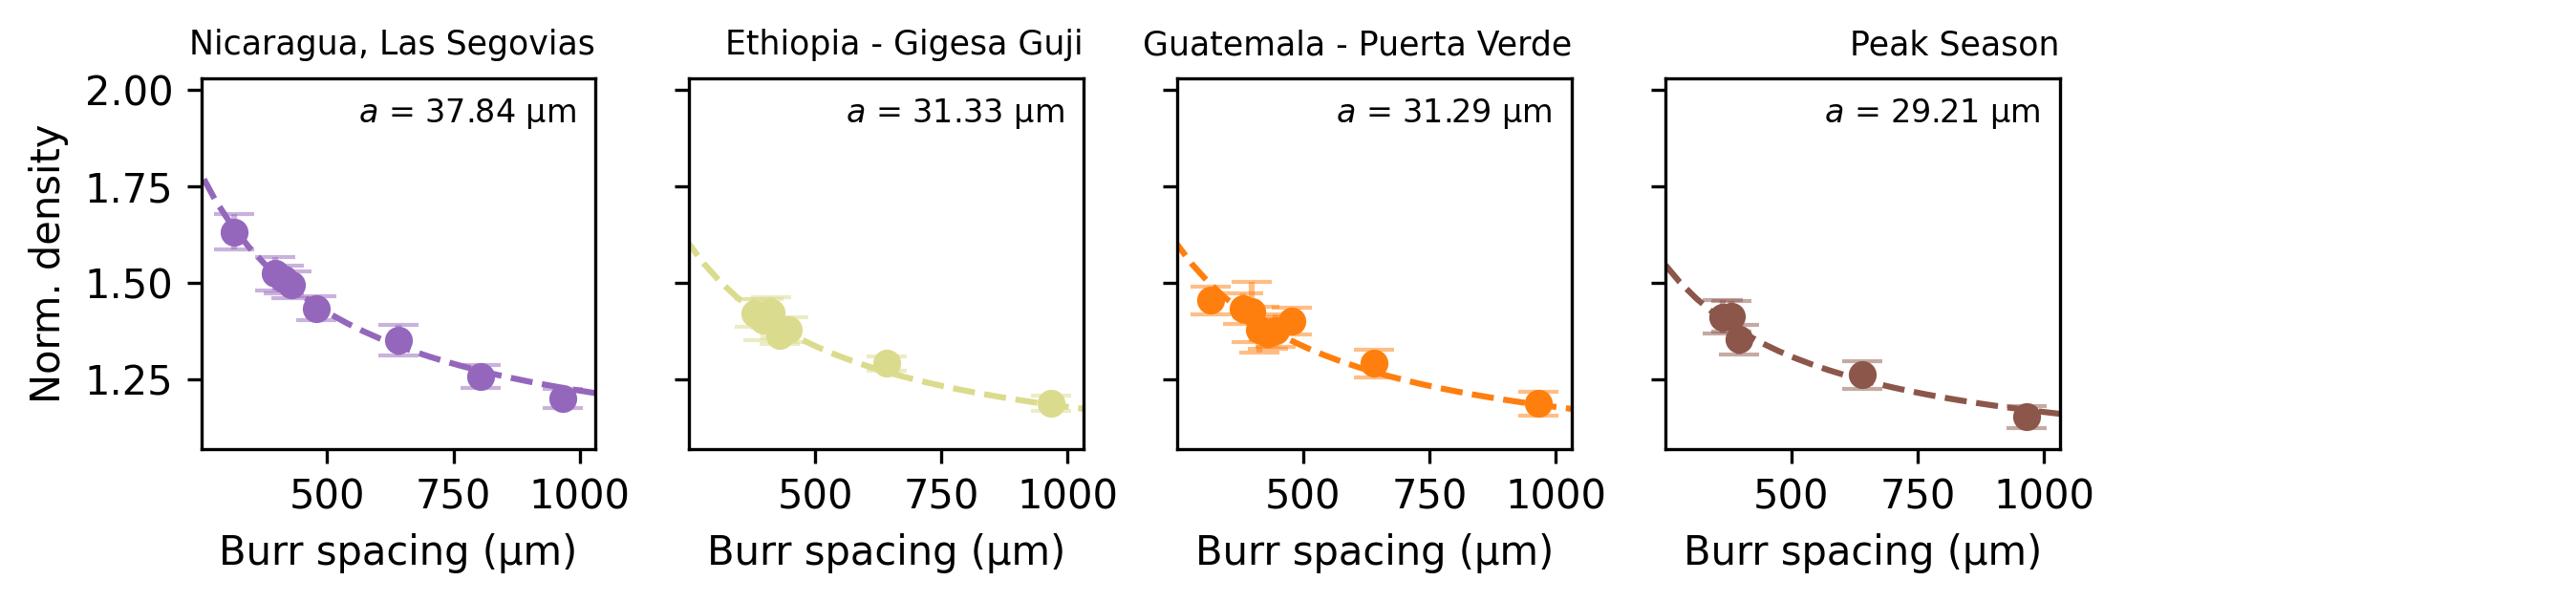

In [44]:
# Define the number of columns for subplots
ncols = 5

for grinder_id in unique_grinder_ids:
    # Get trials for this grinder
    trials_this_grinder = ground_trials[grinder_ids == grinder_id]

    # Get unique bag ID's for this grinder
    bag_ids_this_grinder = bag_ids[grinder_ids == grinder_id]
    unique_bag_ids = np.unique(bag_ids_this_grinder)
    
    # Calculate the number of rows needed
    nrows = int(np.ceil(len(unique_bag_ids) / ncols))
    
    # Create a figure or this grinder
    fig, axs = plt.subplots(nrows=nrows, ncols=ncols, figsize=(9,8.5/ncols*nrows+0.5), sharex=True, sharey=True, dpi=300)
    fig.patch.set_facecolor('none')

    # Grinder label
    print(grinders.loc[grinder_id].description)

    plot_count = 0
    for i, (bag_id, label, _) in enumerate(bag_info_with_fit):
        if bag_id not in a_results:
            continue
        
        # Get plot color
        color = bag_colors[i]
        
        # Get trials for this bag
        trials_this_bag = trials[trial_bag_ids == bag_id]
        grinder_ids_this_bag = trial_grinder_ids[trial_bag_ids == bag_id]
        
        # Intialize label
        samples_found = False
        
        # Separate into beans and ground coffee
        has_grinder_id = ~np.isnan(grinder_ids_this_bag)
        
        # Get bean trials
        bean_trials_this_bag = trials_this_bag[~has_grinder_id]
        
        # Get ground trials
        ground_trials_this_bag = trials_this_bag[grinder_ids_this_bag == grinder_id]
    
        if not bean_trials_this_bag.empty:
            # Get bean densities
            bean_densities_mean = bean_trials_this_bag.density.mean()
            bean_densities_std = bean_trials_this_bag.density.std()

            burr_spacings_this_bag = trial_burr_spacing[trial_bag_ids == bag_id]
            burr_spacings_this_bag = burr_spacings_this_bag[grinder_ids_this_bag == grinder_id]
            
            for burr_spacing in np.unique(burr_spacings_this_bag):
                # Get trials with this grind setting
                trials_this_grind = ground_trials_this_bag[burr_spacings_this_bag == burr_spacing]
        
                # Skip outliers
                #sub = trials_this_grind[[s not in outliers for s in trials_this_grind.sample_id]]
                sub = trials_this_grind

                if not sub.empty:
                    # Get axis for this bag
                    if (nrows == 1):
                        ax = axs[plot_count]
                    else:
                        ax = axs[int(plot_count / ncols), plot_count % ncols]
                    
                    # Get ground densities
                    ground_densities = trials_this_grind.density
    
                    # Calculate mean and standard deviation
                    ys = ground_densities.mean() / bean_densities_mean
                    yerrs = np.sqrt((ground_densities.std() / bean_densities_mean)**2 + 
                                    (ground_densities.mean() / bean_densities_mean**2 * bean_densities_std)**2) * 1.96
            
                    # Plot
                    if len(ground_densities) > 1:
                        ax.errorbar(burr_spacing, ys, yerr=yerrs, fmt='none', capsize=5, color=color, alpha=0.5)
                    ax.scatter(burr_spacing, ys, color=color, label=label)
            
                    # Mark as found
                    samples_found = True

        if samples_found:
            # Plot the fit
            xs = np.linspace(d0_results[grinder_id] + 200, d0_results[grinder_id] + 1800)
            ys = density_func(xs, d0_results[grinder_id], a_results[bag_id])
            ax.plot(xs, ys, ls='--', color=color)
            
            # Add text to plot
            ax.text(0.95, 0.95, f'$a$ = {a_results[bag_id]:.2f} µm', fontsize=8, 
                     horizontalalignment='right', verticalalignment='top', 
                     transform=ax.transAxes)

            # Set axis labels
            if int(plot_count / ncols) == nrows - 1:
                ax.set_xlabel("Burr spacing (µm)")
            if plot_count % ncols == 0:
                ax.set_ylabel('Norm. density')

            # Add title to the subplot
            ax.set_title(label, loc='right', fontsize='small')
            
            # Get plot limits
            x1 = d0_results[grinder_id] + xmin
            x2 = d0_results[grinder_id] + xmax
            ax.set_xlim(x1, x2)
            ax.set_ylim(ylim)

            ax.xaxis.set_major_locator(MultipleLocator(250))
    
            plot_count += 1
    
    # Hide unused axes
    for i in range(plot_count, nrows * ncols):
        if (nrows == 1):
            axs[i].axis('off')
        else:
            axs[int(i / ncols), i % ncols].axis('off')
    
    plt.tight_layout()
    plt.show()

Now let's plot the thickness of the surface layer, $a$, vs. bean specific volume.

C:\Users\crwpe\AppData\Local\Temp\ipykernel_18852\688810822.py:42: RuntimeWarning: invalid value encountered in power
  return a * (x - x0)**(1/3)


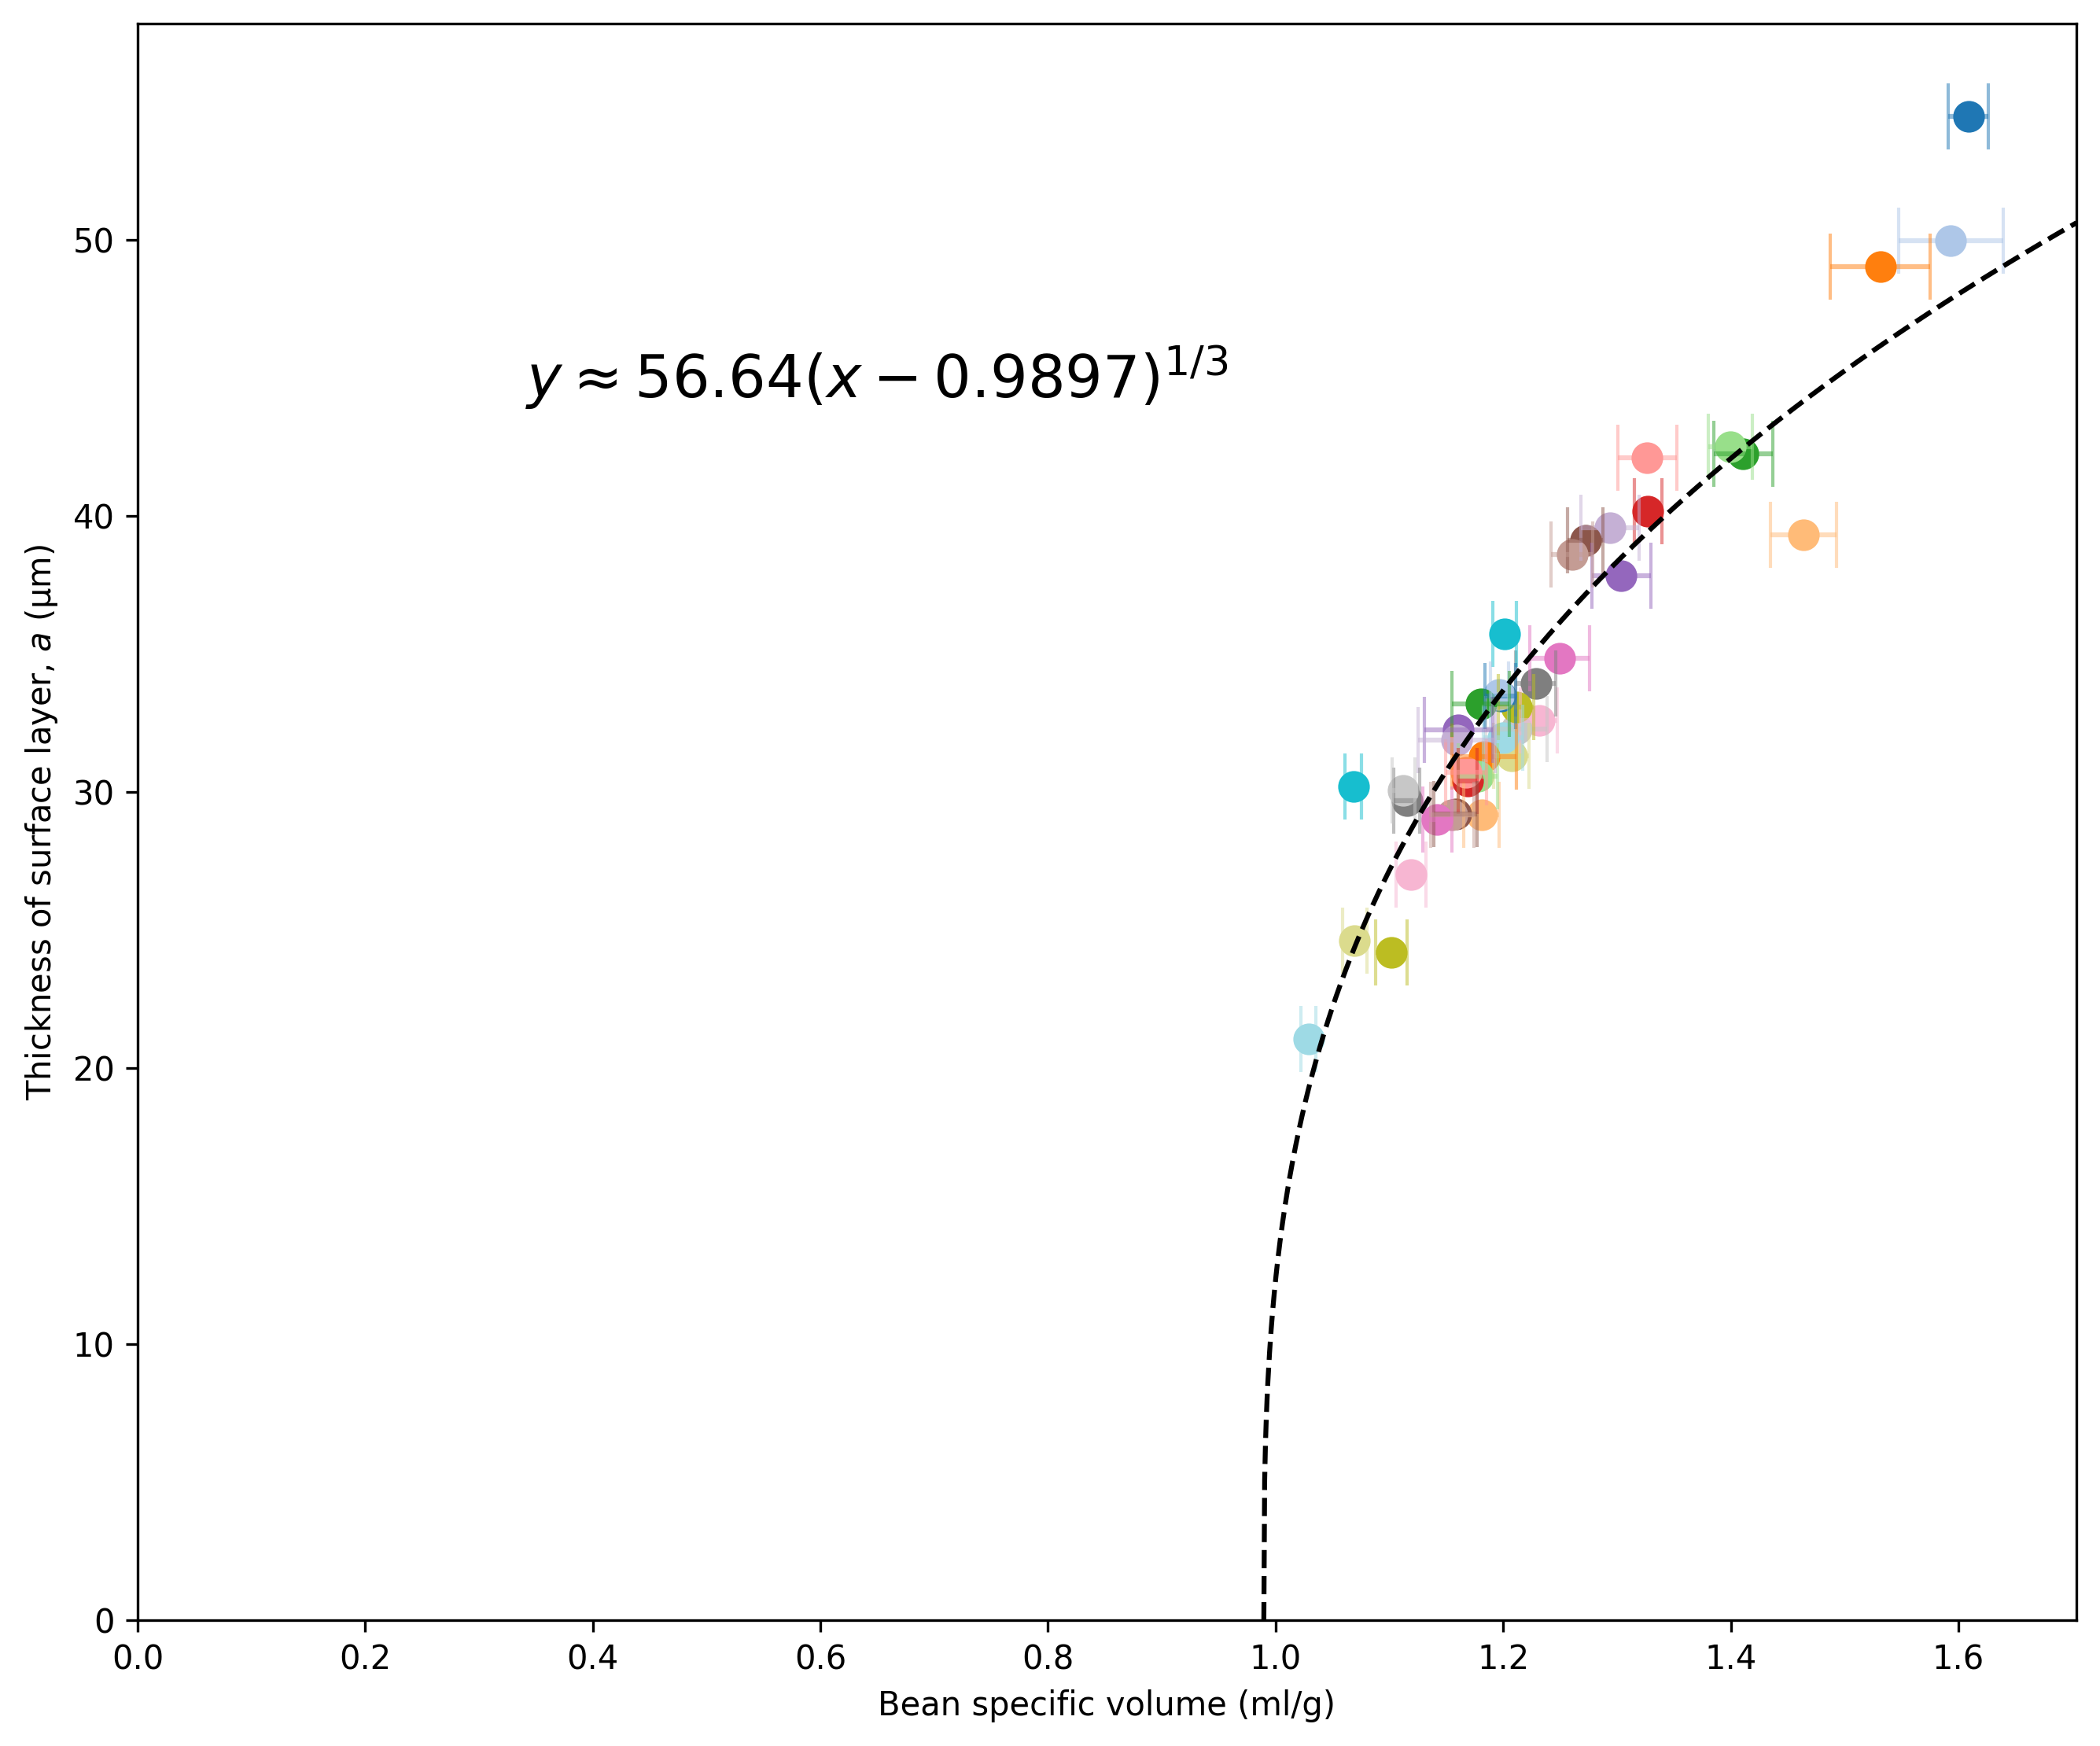

array([ 0.98970395, 56.64338174])

In [45]:
# Create the figure
fig, ax = plt.subplots(figsize=(9,7.5), dpi=300)
fig.patch.set_facecolor('none')

# Initialize data
xs = []
ys = []

for i, (bag_id, label, _) in enumerate(bag_info_with_fit):
    # Get samples for this bag
    samples_this_bag = samples[samples.bag_id == bag_id]
    
    # Separate into beans and ground coffee
    has_grind_setting = ~samples_this_bag.grind_setting.isna()
    
    # Get bean trials
    bean_samples = samples_this_bag[~has_grind_setting]
    bean_trials = trials[[s in bean_samples.index for s in trials.sample_id]]

    if bag_id in a_results.keys() and not bean_trials.empty:
        # Get bean densities
        bean_volumes_mean = (1 / bean_trials.density).mean()
        bean_volumes_std = (1 / bean_trials.density).std()

        # Save data
        xs.append(bean_volumes_mean)
        ys.append(a_results[bag_id])

        ax.errorbar(bean_volumes_mean, a_results[bag_id], xerr=bean_volumes_std * 1.96, 
                    fmt='none', capsize=10, color=bag_colors[i], alpha=0.5)
        ax.scatter(bean_volumes_mean, a_results[bag_id], color=bag_colors[i], label=label, 
                   marker='o', s=75)

# Set axis ranges
xlim = (0, plt.xlim()[1] * 1.02)
ylim = (0, plt.ylim()[1] * 1.03)

plt.xlim(*xlim)
plt.ylim(*ylim)

def roast_func(x, x0, a):
    return a * (x - x0)**(1/3)

# Get curve fit
params, cov = curve_fit(roast_func, xs, ys, p0=(1.0, 1.0))

# Plot the fit
xs = np.linspace(params[0], xlim[1], 1000)
ys = roast_func(xs, *params)
ax.plot(xs, ys, ls='--', color='k')

# Plot the fit function
ax.text(0.2, 0.8, 
        f'$y \\approx {params[1]:.02f} (x - {params[0]:.04f})^{{1/3}}$', 
        verticalalignment='top', horizontalalignment='left', transform=ax.transAxes, fontsize=18)

# Set axis labels
ax.set_xlabel('Bean specific volume (ml/g)')
ax.set_ylabel('Thickness of surface layer, $a$ (µm)')

plt.tight_layout()
plt.show()

params

The dashed line shows a cube root fit to the data. This might form a trajectory along which coffee travels during the roasting process.

# Variation in tamped coffee density with grind setting

We start by calculating burr spacing for each measurement.

In [46]:
def get_burr_spacing(row):
    if not np.isnan(row.grinder_cal_id):
        grinder_cal = grinder_cals.loc[row.grinder_cal_id]
        burr_spacing = (row.grind_setting - grinder_cal.zero_digits) * grinder_cal.um_per_digit
    else:
        burr_spacing = np.nan
    return pd.Series([burr_spacing], index=['burr_spacing'])

depths['burr_spacing'] = depths.apply(get_burr_spacing, axis = 1)
depths.tail()

,bag_id,grinder_cal_id,basket_id,tamp_force_kg,grind_setting,weight_in_basket,depth_below_rim,burr_spacing
id,,,,,,,,
1483,161.0,14,5,15.17,4.4,17.99,13.00,180.0
1485,161.0,14,5,15.34,4.8,18.01,12.61,192.0
1486,161.0,14,5,15.48,4.8,18.00,12.51,192.0
1487,161.0,14,5,15.44,2.8,17.99,13.79,132.0
1488,161.0,14,5,15.48,2.8,17.99,13.97,132.0


Then we need to add grinder information to `depths` and `samples`.

In [47]:
def get_grinder_id(row):
    grinder_cal_id = row.grinder_cal_id
    if ~np.isnan(grinder_cal_id):
        return grinder_cals.loc[grinder_cal_id].grinder_id
    else:
        return np.nan

depths['grinder_id'] = depths.apply(get_grinder_id, axis = 1)
depths.tail()

,bag_id,grinder_cal_id,basket_id,tamp_force_kg,grind_setting,weight_in_basket,depth_below_rim,burr_spacing,grinder_id
id,,,,,,,,,
1483,161.0,14,5,15.17,4.4,17.99,13.00,180.0,3
1485,161.0,14,5,15.34,4.8,18.01,12.61,192.0,3
1486,161.0,14,5,15.48,4.8,18.00,12.51,192.0,3
1487,161.0,14,5,15.44,2.8,17.99,13.79,132.0,3
1488,161.0,14,5,15.48,2.8,17.99,13.97,132.0,3


In [48]:
samples['grinder_id'] = samples.apply(get_grinder_id, axis = 1)
samples.tail()

,date,weight,volume,bag_id,grinder_cal_id,grind_setting,shot_id,depth_id,method_id,description,notes,burr_spacing,grinder_id
id,,,,,,,,,,,,,
1049,2025-03-09,269.25,34.05,NaN,NaN,NaN,NaN,NaN,9,75 balls (old),NaN,NaN,NaN
1050,2025-03-10,18.11,NaN,161.0,14.0,2.8,2013.0,1487.0,9,Boa Bedegelo (2.80) ground,NaN,132.0,3.0
1051,2025-03-10,18.10,NaN,161.0,14.0,2.8,2014.0,1488.0,9,Boa Bedegelo (2.80) ground,NaN,132.0,3.0
1052,2025-03-10,0.00,0.00,NaN,NaN,NaN,NaN,NaN,9,Empty,NaN,NaN,NaN
1053,2025-03-10,269.36,34.05,NaN,NaN,NaN,NaN,NaN,9,75 balls (old),NaN,NaN,NaN


We will want to consider only bags which actually have all the data we need.

In [49]:
# Collect the "usable" bag IDs (i.e., those that have data)
bag_ids_with_data = []
for i, (bag_id, label, _) in enumerate(bag_info):
    # Check if this bag_id is present and non-empty
    mask_bag = samples.bag_id == bag_id
    mask_depths = depths.bag_id == bag_id
    
    # Only consider it "usable" if there's *some* actual data
    # (e.g., not all rows are empty, or however you define "has data")
    if mask_bag.any() and mask_depths.any():
        bag_ids_with_data.append(bag_id)

bag_info_with_tamp = [bag for bag in bag_info if bag[0] in bag_ids_with_data]

Then we plot normalized tamped coffee density vs. burr spacing.

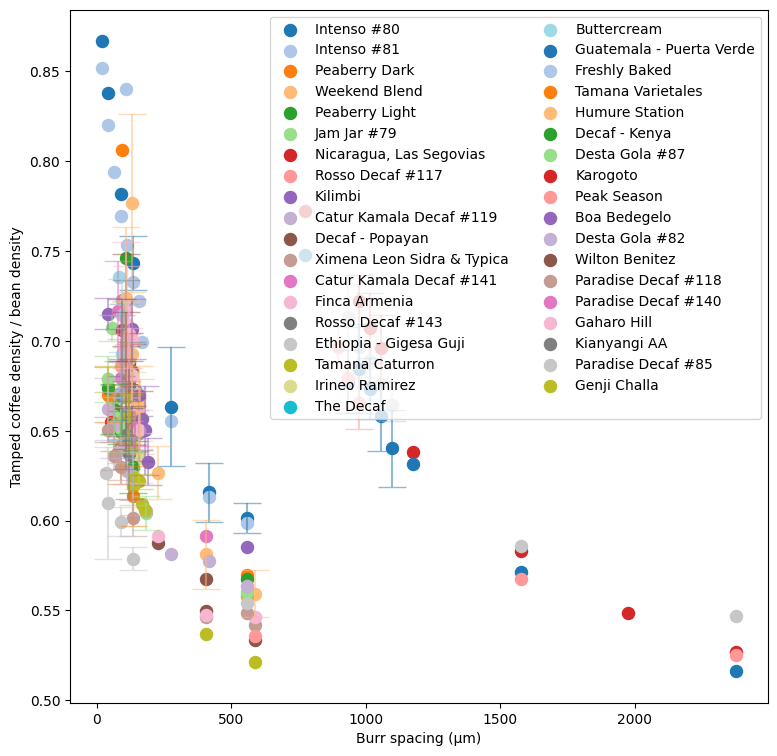

In [50]:
# Create the figure
fig, ax = plt.subplots(figsize=(9,9))
fig.patch.set_facecolor('white')

for i, (bag_id, label, _) in enumerate(bag_info_with_tamp):
    # Get samples for this bag
    samples_this_bag = samples[samples.bag_id == bag_id]
    
    # Separate into beans and ground coffee
    has_grind_setting = ~samples_this_bag.grind_setting.isna()
    
    # Get depths for this bag
    depths_this_bag = depths[depths.bag_id == bag_id]

    # Get bean trials
    bean_samples = samples_this_bag[~has_grind_setting]
    bean_trials = trials[[s in bean_samples.index for s in trials.sample_id]]
    
    if not depths_this_bag.empty and not bean_trials.empty:
        # Get bean densities
        bean_densities_mean = bean_trials.density.mean()
        bean_densities_std = bean_trials.density.std()

        for burr_spacing in depths_this_bag.burr_spacing.unique():
            # Get depth measurements
            depths_this_grind = depths_this_bag[depths_this_bag.burr_spacing == burr_spacing]
        
            if not depths_this_grind.empty:
                # Calculate tamped densities
                volumes = depths_this_grind.apply(get_volume, axis=1)
                tamped_densities = depths_this_grind.weight_in_basket / volumes
                
                # Calculate mean and standard deviation
                ys = tamped_densities.mean() / bean_densities_mean
                yerrs = np.sqrt((tamped_densities.std() / bean_densities_mean)**2 + 
                                (tamped_densities.mean() / bean_densities_mean**2 * bean_densities_std)**2) * 1.96
        
                # Plot
                if len(depths_this_grind) > 1:
                    ax.errorbar(burr_spacing, ys, yerr=yerrs, fmt='none', capsize=10, color=bag_colors[i], alpha=0.5)
                ax.scatter(burr_spacing, ys, color=bag_colors[i], label=label, s=75)
        
                # Reset label
                label = None

# Get plot limits
xlim = ax.set_xlim()
ylim = ax.get_ylim()

# Set axis labels
ax.set_xlabel('Burr spacing (µm)')
ax.set_ylabel('Tamped coffee density / bean density')

# Draw legend
plt.legend(loc='upper right', ncol=2)

We can calculate void ratio as:

$$
\text{Void Ratio} = \frac{\text{Ground Density}}{\text{Tamped Density}} - 1
$$

What if we plot void ratio vs. burr spacing?

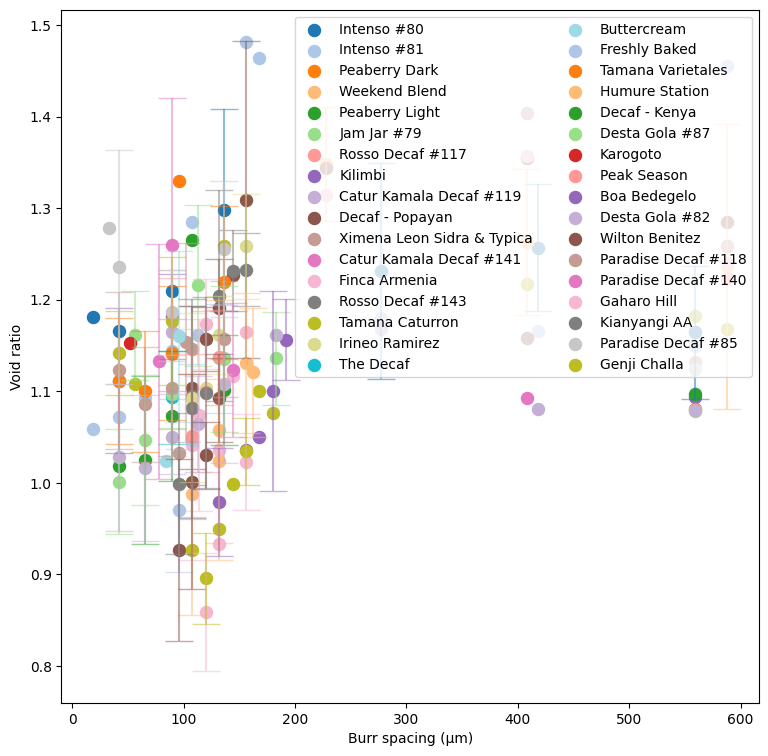

In [51]:
# Create the figure
fig, ax = plt.subplots(figsize=(9,9))
fig.patch.set_facecolor('white')

for i, (bag_id, label, _) in enumerate(bag_info_with_tamp):
    # Get samples for this bag
    samples_this_bag = samples[samples.bag_id == bag_id]
    
    # Separate into beans and ground coffee
    has_grind_setting = ~samples_this_bag.grind_setting.isna()
    
    # Get depths for this bag
    depths_this_bag = depths[depths.bag_id == bag_id]

    for burr_spacing in depths_this_bag.burr_spacing.unique():
        # Get depth measurements
        depths_this_grind = depths_this_bag[depths_this_bag.burr_spacing == burr_spacing]
    
        # Get ground trials
        ground_samples = samples_this_bag[has_grind_setting & (samples_this_bag.burr_spacing == burr_spacing)]
        ground_trials = trials[[s in ground_samples.index for s in trials.sample_id]]
        
        if not depths_this_grind.empty and not ground_trials.empty:
            # Get ground densities
            ground_densities = ground_trials.density
            
            # Calculate tamped densities
            volumes = depths_this_grind.apply(get_volume, axis=1)
            tamped_densities = depths_this_grind.weight_in_basket / volumes
            
            # Calculate plot values
            ys = ground_densities.mean() / tamped_densities.mean() - 1
            yerrs = np.sqrt((ground_densities.std() / tamped_densities.mean())**2 + 
                            (ground_densities.mean() / tamped_densities.mean()**2 * tamped_densities.std())**2) * 1.96

            # Plot
            if len(ground_densities) > 1 and len(tamped_densities) > 1:
                ax.errorbar(burr_spacing, ys, yerr=yerrs, fmt='none', capsize=10, color=bag_colors[i], alpha=0.5)
            ax.scatter(burr_spacing, ys, color=bag_colors[i], label=label, s=75)
    
            # Reset label
            label = None

# Get plot limits
xlim = ax.get_xlim()
ylim = ax.get_ylim()

# Set axis labels
ax.set_xlabel('Burr spacing (µm)')
ax.set_ylabel('Void ratio')

# Draw legend
plt.legend(loc='upper right', ncol=2)

Let's split these into separate subplots.

Eureka Mignon Specialita


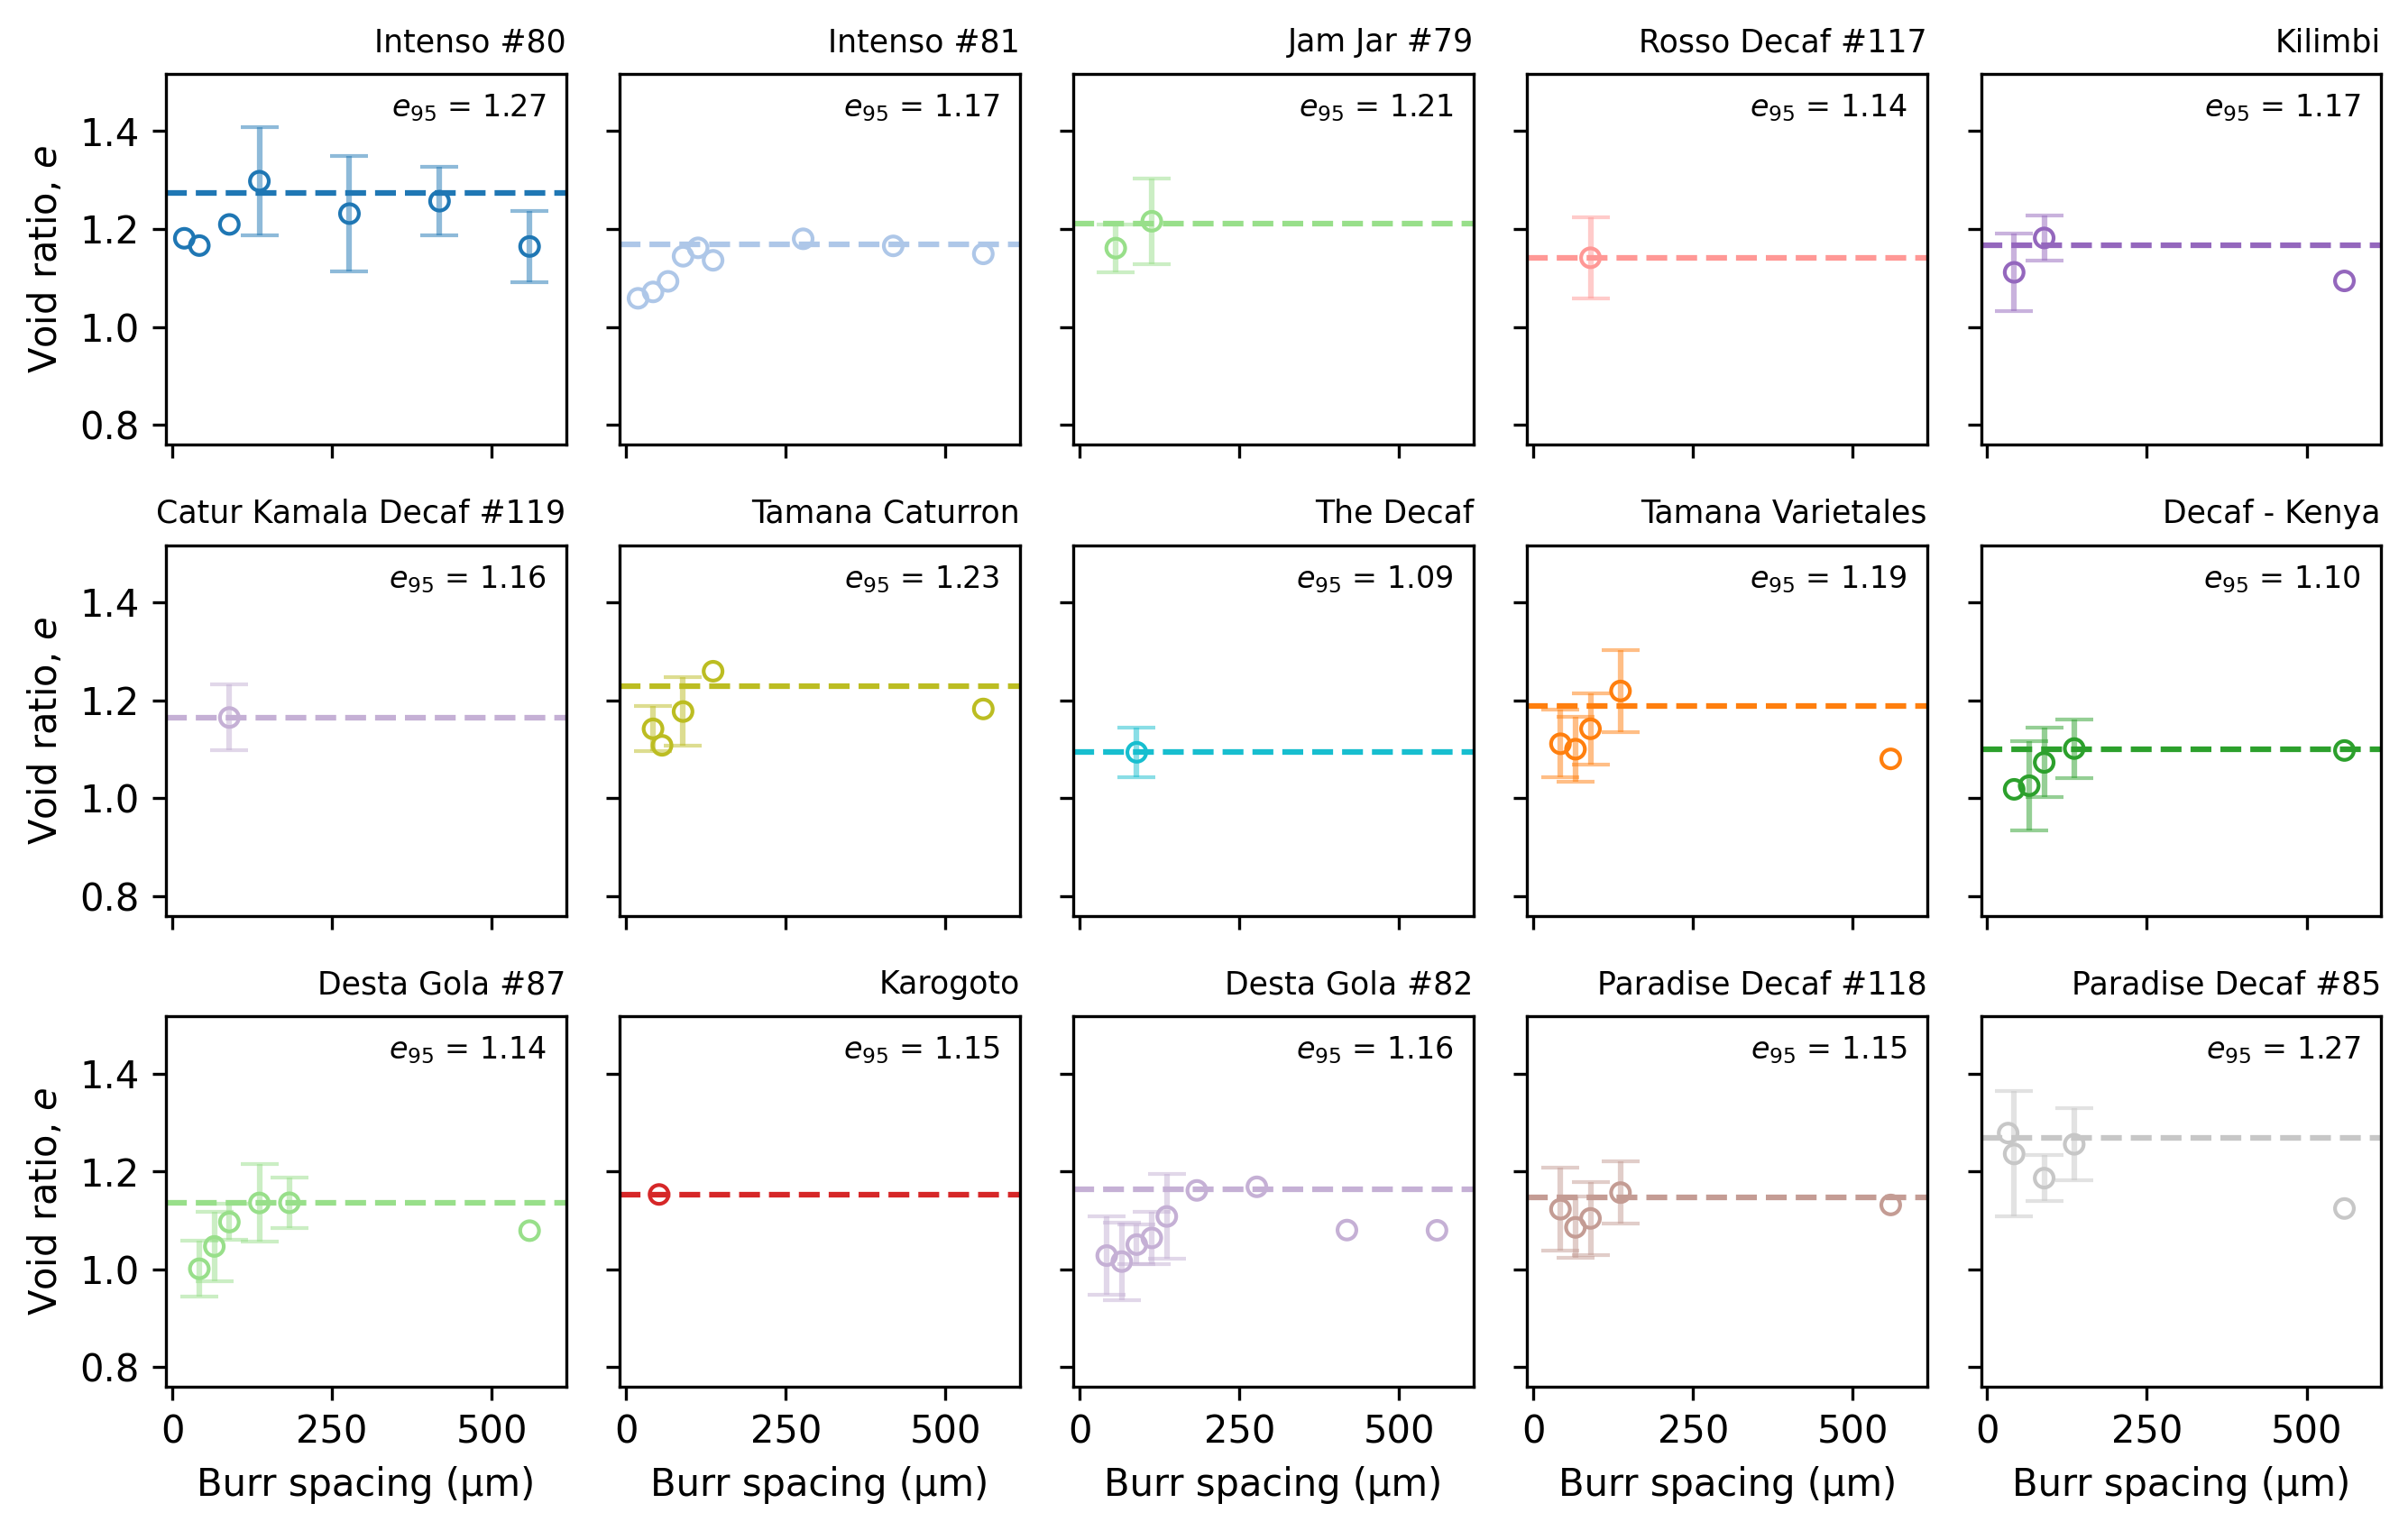

Timemore Sculptor 078S


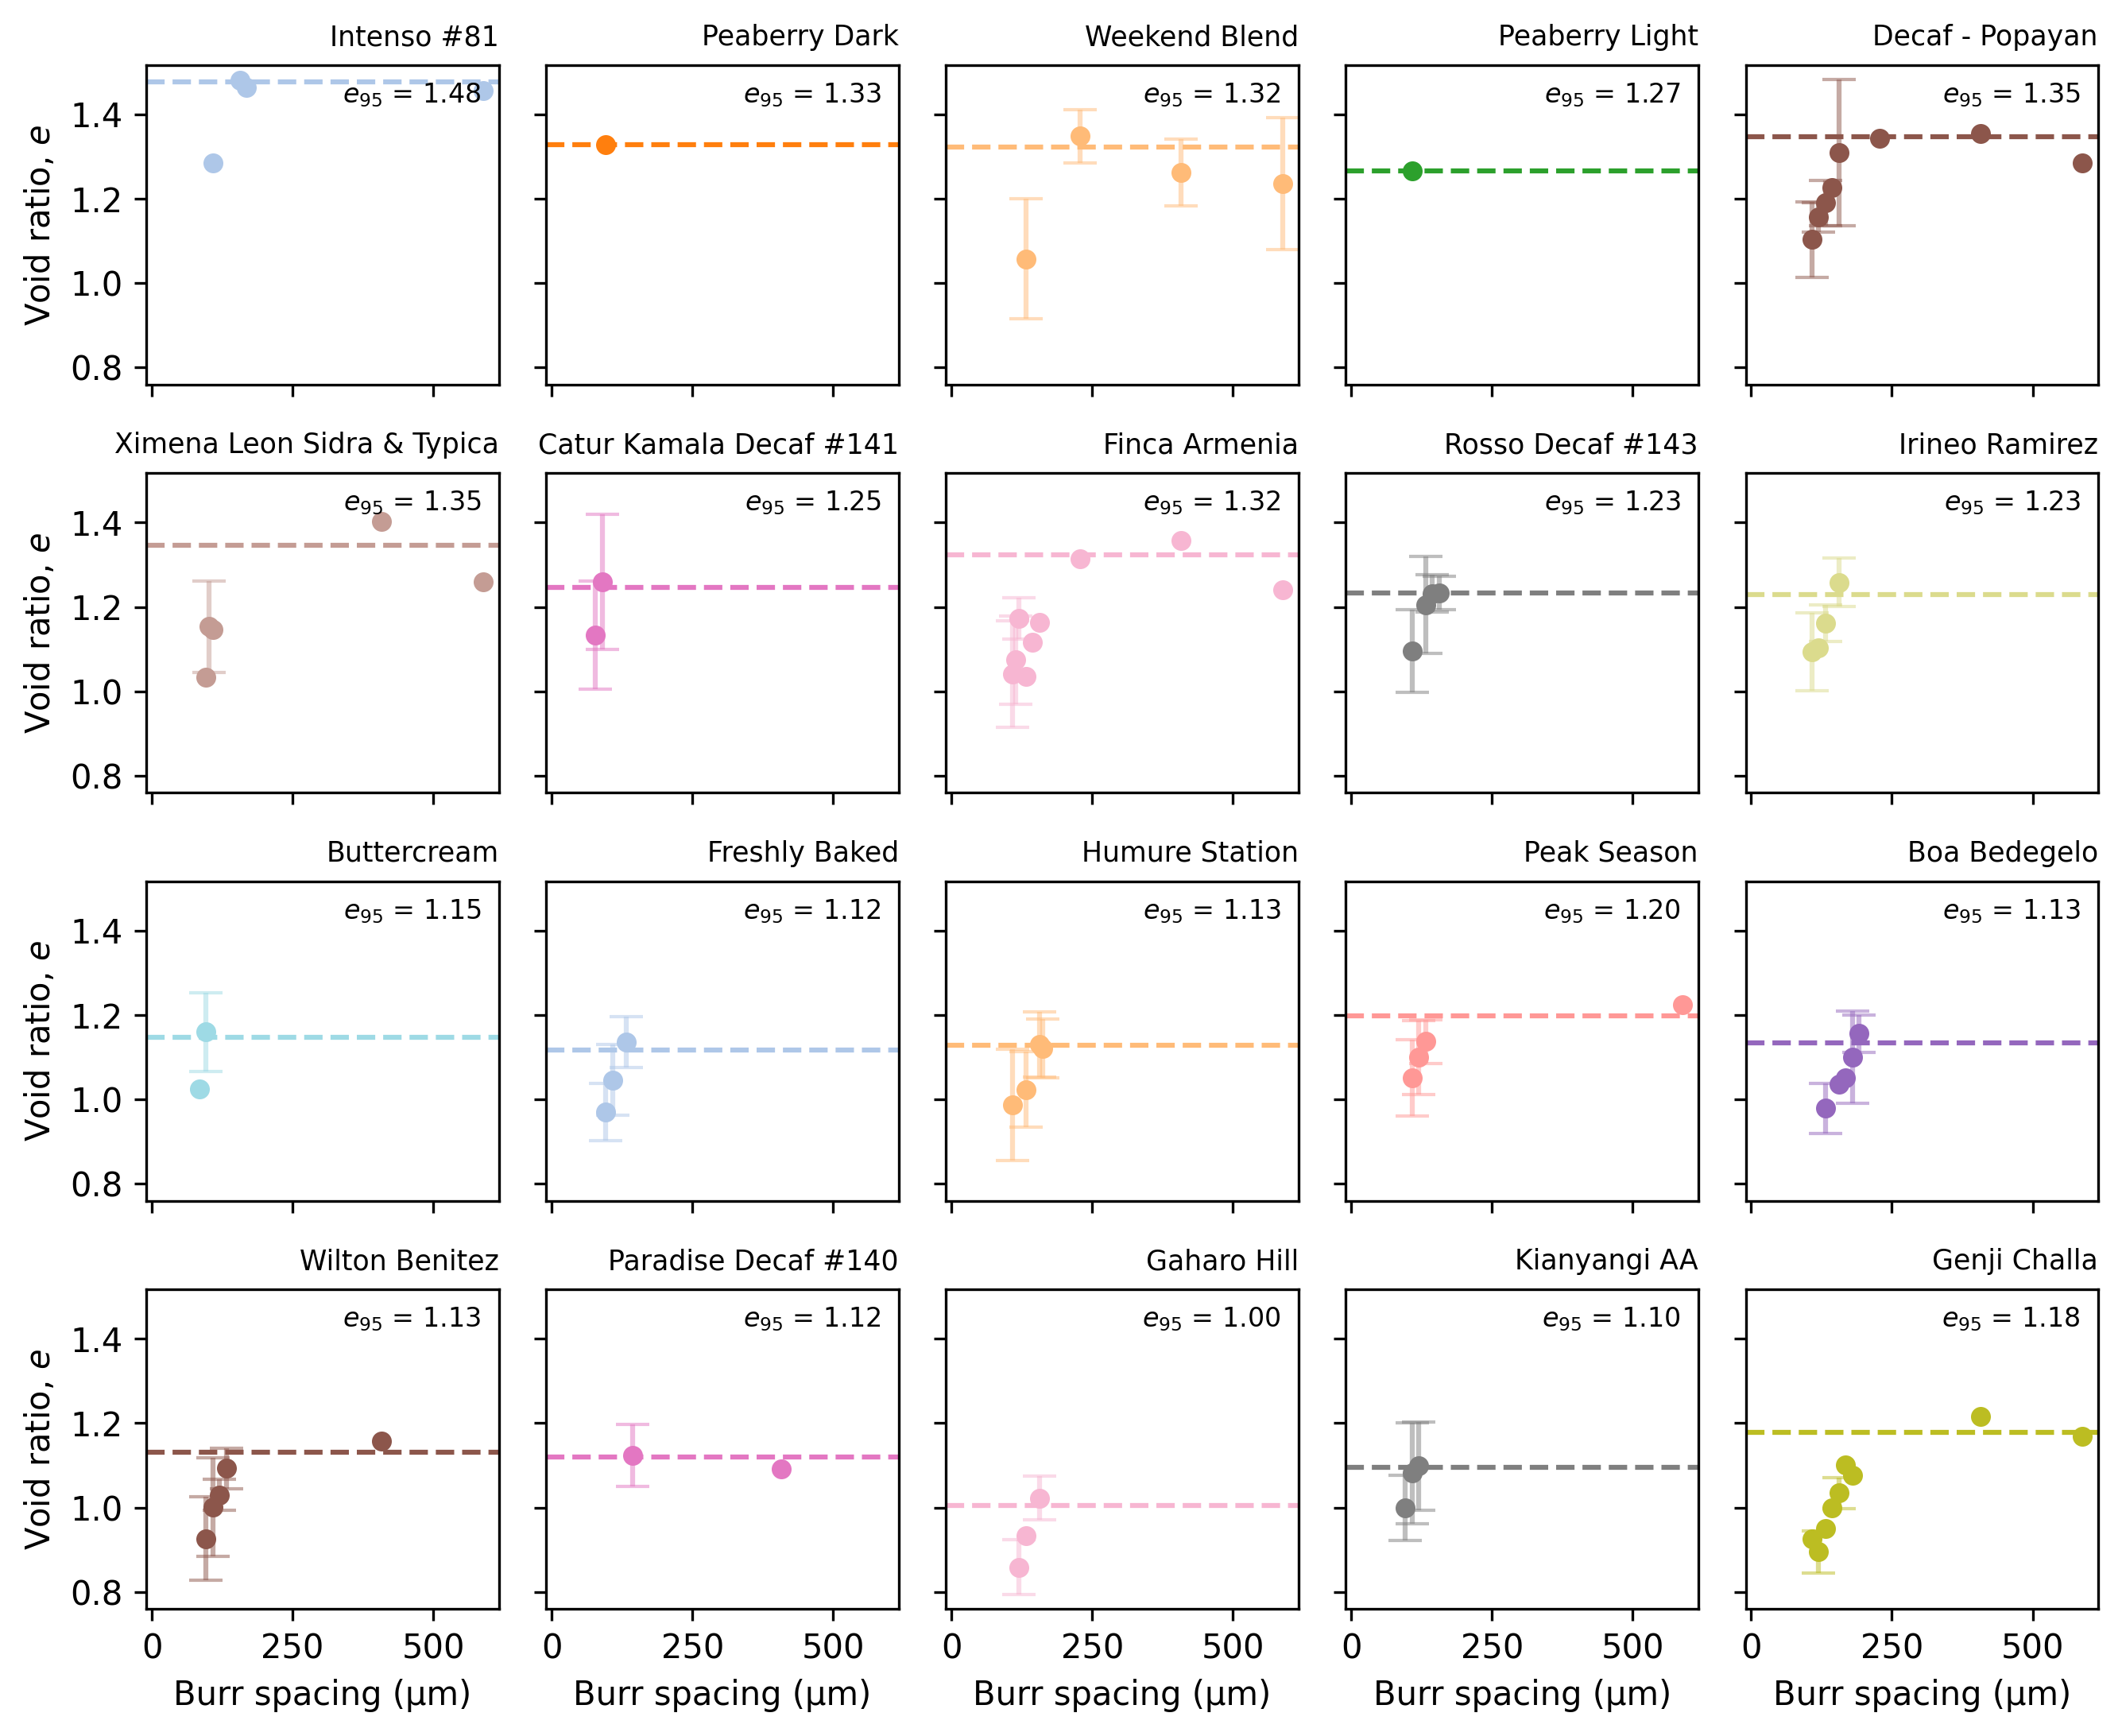

1Zpresso J-Ultra


<Figure size 2700x756 with 0 Axes>

In [52]:
# Define the number of columns for subplots
ncols = 5

for grinder_id in unique_grinder_ids:
    # Get samples for this grinder
    samples_this_grinder = samples[samples.grinder_id == grinder_id]

    # Get unique bag ID's for this grinder
    unique_bag_ids = samples_this_grinder.bag_id.unique()
    if len(unique_bag_ids) == 0: continue
    
    # Get depths for this grinder
    depths_this_grinder = depths[depths.grinder_id == grinder_id]

    # Collect the "usable" bag IDs (i.e., those that have data)
    bag_ids_with_data = []
    for i, (bag_id, label, _) in enumerate(bag_info_with_tamp):
        # Check if this bag_id is present and non-empty
        mask_bag = samples_this_grinder.bag_id == bag_id
        mask_depths = depths_this_grinder.bag_id == bag_id
        
        # Only consider it "usable" if there's *some* actual data
        # (e.g., not all rows are empty, or however you define "has data")
        if mask_bag.any() and mask_depths.any():
            bag_ids_with_data.append(bag_id)
    
    # Now bag_ids_with_data holds only the bag IDs that will produce plots
    num_plots = len(bag_ids_with_data)
    if num_plots == 0:
        continue  # no subplots needed for this grinder, skip
    
    # Calculate the number of rows needed
    nrows = int(np.ceil(num_plots / ncols))
    
    # Create a figure for this grinder
    fig, axs = plt.subplots(nrows=nrows, ncols=ncols, figsize=(9,8.1/ncols*nrows+0.9), sharex=True, sharey=True, dpi=300)
    fig.patch.set_facecolor('none')

    # Grinder label
    print(grinders.loc[grinder_id].description)

    plot_count = 0
    for i, (bag_id, label, _) in enumerate(bag_info_with_tamp):
        # Get plot color
        color = bag_colors[i]

        # Get samples for this bag
        samples_this_bag = samples_this_grinder[samples_this_grinder.bag_id == bag_id]
        
        # Get depths for this bag
        depths_this_bag = depths[depths.bag_id == bag_id]
    
        # Initialize value list
        vals = []
    
        for burr_spacing in depths_this_bag.burr_spacing.unique():
            # Get samples for this grind setting
            samples_this_grind = samples_this_bag[samples_this_bag.burr_spacing == burr_spacing]
            
            # Get depth measurements
            depths_this_grind = depths_this_bag[depths_this_bag.burr_spacing == burr_spacing]
        
            # Get ground trials
            ground_samples = samples_this_grind[~samples_this_grind.grind_setting.isna()]
            ground_trials = trials[[s in ground_samples.index for s in trials.sample_id]]

            if not depths_this_grind.empty and not ground_trials.empty:
                # Get axis for this bag
                if (nrows == 1):
                    ax = axs[plot_count]
                else:
                    ax = axs[int(plot_count / ncols), plot_count % ncols]

                # Get ground densities
                ground_densities = ground_trials.density
                
                # Calculate tamped densities
                volumes = depths_this_grind.apply(get_volume, axis=1)
                tamped_densities = depths_this_grind.weight_in_basket / volumes
                
                # Calculate plot values
                ys = ground_densities.mean() / tamped_densities.mean() - 1
                yerrs = np.sqrt((ground_densities.std() / tamped_densities.mean())**2 + 
                                (ground_densities.mean() / tamped_densities.mean()**2 * tamped_densities.std())**2) * 1.96

                # Get fill colour
                mfc = depths_this_grind.apply(
                    lambda row: bag_colors[i] if row.grinder_id == 3 else 'none', 
                    axis=1).values[0]
                mec = bag_colors[i]
    
                # Plot
                if len(ground_densities) > 1 and len(tamped_densities) > 1:
                    ax.errorbar(burr_spacing, ys, yerr=yerrs, fmt='none', capsize=5, alpha=0.5, mfc=mfc, mec=mec, ecolor=mec)
                ax.scatter(burr_spacing, ys, label=label, s=25, facecolors=mfc, edgecolors=mec)
    
                # Append to values list
                vals.append(ys)
                
                # Mark as found
                samples_found = True
    
        if len(vals):
            # Calculate void ratio for dotted line
            avg = np.percentile(vals, 90)
    
            # Plot average
            xs = np.linspace(*xlim)
            ys = np.array([avg] * len(xs))
            ax.plot(xs, ys, ls='--', color=bag_colors[i])
            
            # Add average to plot
            ax.text(0.95, 0.95, f'$e_{{95}}$ = {avg:.2f}', fontsize=8, 
                     horizontalalignment='right', verticalalignment='top', 
                     transform=ax.transAxes)

            # Set axis labels
            if int(plot_count / ncols) == nrows - 1:
                ax.set_xlabel("Burr spacing (µm)")
            if plot_count % ncols == 0:
                ax.set_ylabel(f'Void ratio, $e$')

            # Add title to the subplot
            ax.set_title(label, loc='right', fontsize='small')
            
            # Get plot limits
            ax.set_xlim(xlim)
            ax.set_ylim(ylim)

            plot_count += 1

    # Hide unused axes
    for i in range(plot_count, nrows * ncols):
        if nrows == 1:
            fig.delaxes(axs[i])
        else:
            fig.delaxes(axs[int(i / ncols), i % ncols])
    
    plt.tight_layout()
    plt.show()

Finally, we can calculate an improved fit.

--- Fitting Results ---
Global parameter epsilon_0: 1.9887
Global parameter epsilon_b: -0.8280

Per-grinder parameter delta_phi (µm):
  Grinder ID 3 (Timemore Sculptor 078S): 68.19

Per-grinder parameter d_0 (µm):
  Grinder ID 3 (Timemore Sculptor 078S): 6336985.19

Per-coffee parameter Gamma (µm):
  Karogoto                 : 0.000
  Catur Kamala Decaf #141  : 0.040
  Peaberry Dark            : 0.075
  Buttercream              : 0.101
  Intenso #81              : 0.119
  Peaberry Light           : 0.121
  Kianyangi AA             : 0.146
  Ximena Leon Sidra & Typica: 0.163
  Rosso Decaf #143         : 0.177
  Decaf - Popayan          : 0.184
  Irineo Ramirez           : 0.202
  Peak Season              : 0.218
  Freshly Baked            : 0.222
  Wilton Benitez           : 0.240
  Finca Armenia            : 0.260
  Paradise Decaf #140      : 0.278
  Paradise Decaf #118      : 0.297
  Genji Challa             : 0.315
  Humure Station           : 0.328
  Boa Bedegelo             : 0.472

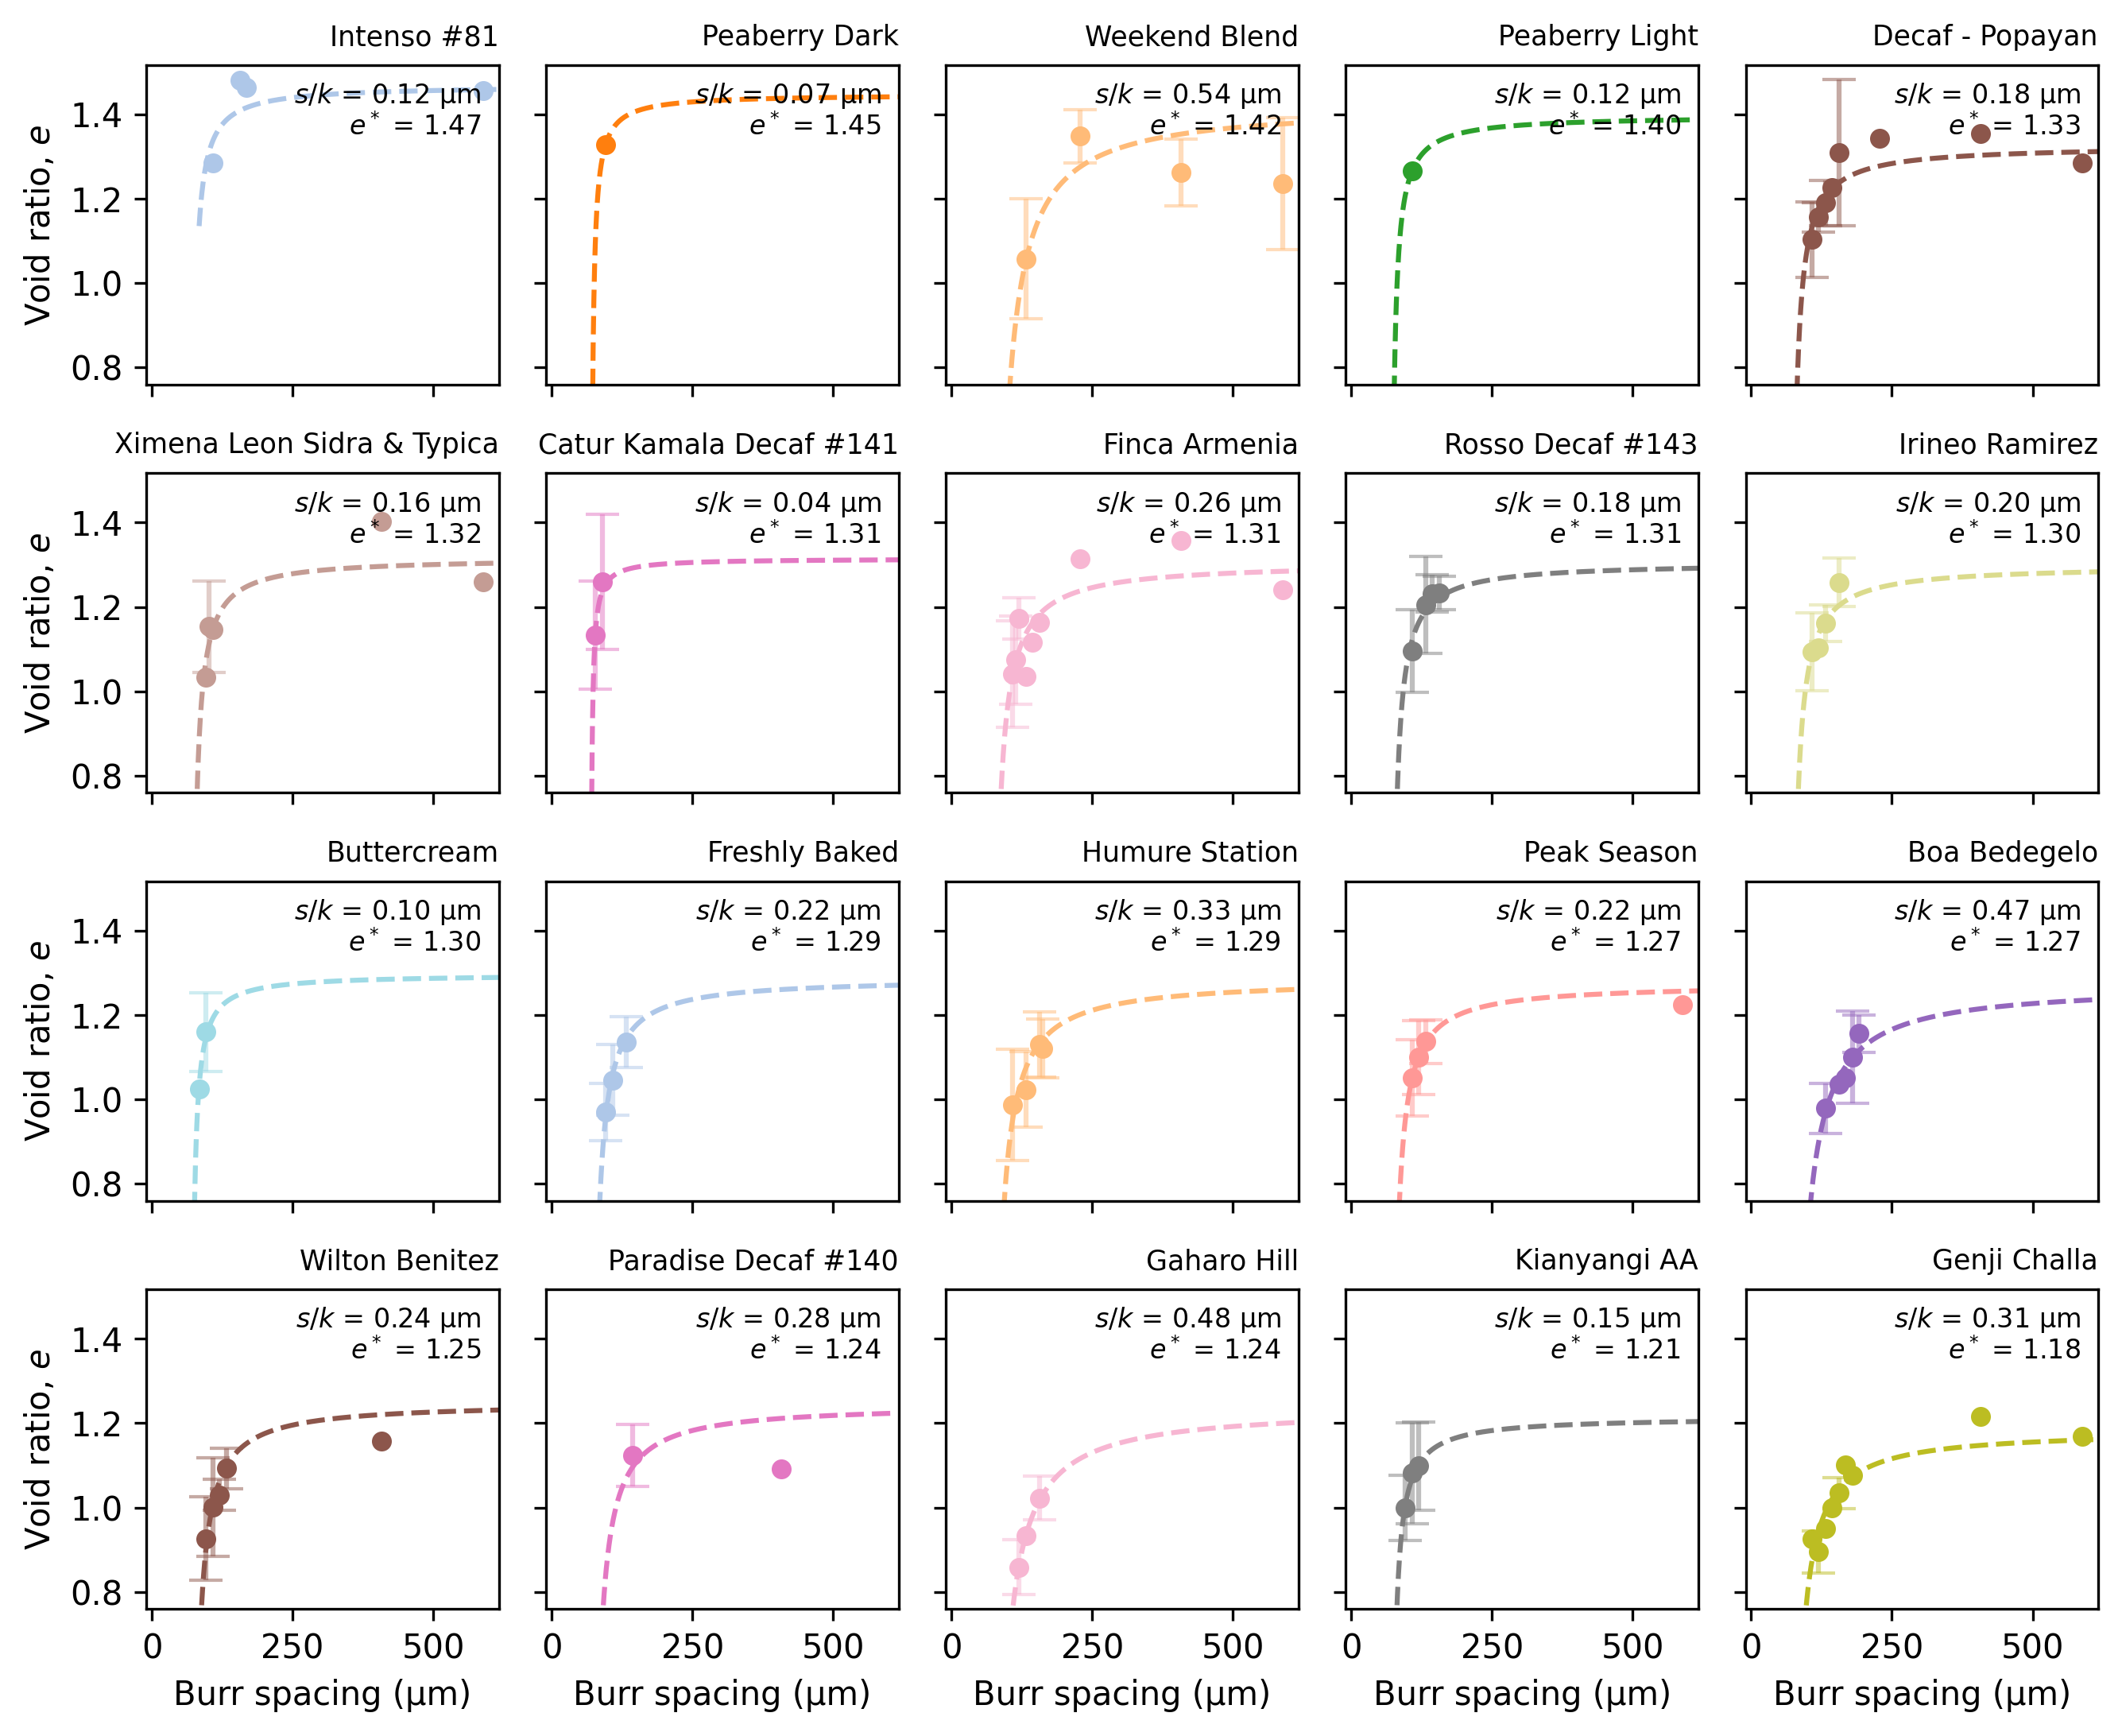

In [53]:
# --- 1. Data Preparation ---

# Get unique grinder and bag IDs that have relevant data in the `depths` table
depths_w_burr = depths.dropna(subset=['burr_spacing', 'grinder_id', 'bag_id'])
# unique_grinder_ids = np.unique(depths_w_burr.grinder_id)
unique_grinder_ids = np.array([3])
unique_bag_ids = np.unique(depths_w_burr.bag_id)

# Create mappings from ID to an integer index for the fitting procedure
grinder_id_to_index = {gid: i for i, gid in enumerate(unique_grinder_ids)}
bag_id_to_index = {bid: i for i, bid in enumerate(unique_bag_ids)}

# Initialize lists to hold the flattened data for fitting
all_burr_spacings = []
all_void_ratios = []
all_bean_densities = []
all_grinder_indices = []
all_bag_indices = []

# Loop through all grinder and bag combinations to gather the data points
for grinder_id in unique_grinder_ids:
    for bag_id in unique_bag_ids:
        # Get data for the current combination
        samples_this_combo = samples[(samples.bag_id == bag_id) & (samples.grinder_id == grinder_id)]
        depths_this_combo = depths[(depths.bag_id == bag_id) & (depths.grinder_id == grinder_id)]
        
        # Get mean bean density for this coffee
        bean_samples = samples[(samples.bag_id == bag_id) & (samples.grind_setting.isna())]
        bean_trials = trials[[s in bean_samples.index for s in trials.sample_id]]
        if bean_trials.empty:
            continue
        rho_b = bean_trials.density.mean()

        # Iterate over each unique grind setting
        for burr_spacing in depths_this_combo.burr_spacing.unique():
            ground_trials_this_grind = trials[[s in samples_this_combo[samples_this_combo.burr_spacing == burr_spacing].index for s in trials.sample_id]]
            depths_this_grind = depths_this_combo[depths_this_combo.burr_spacing == burr_spacing]

            if not ground_trials_this_grind.empty and not depths_this_grind.empty:
                # Calculate mean ground and tamped densities
                ground_density = ground_trials_this_grind.density.mean()
                volumes = depths_this_grind.apply(get_volume, axis=1)
                tamped_density = (depths_this_grind.weight_in_basket / volumes).mean()

                # Calculate the void ratio (e)
                void_ratio = ground_density / tamped_density - 1
                
                # Append all calculated values to our lists
                all_void_ratios.append(void_ratio)
                all_burr_spacings.append(burr_spacing)
                all_bean_densities.append(rho_b)
                all_grinder_indices.append(grinder_id_to_index[grinder_id])
                all_bag_indices.append(bag_id_to_index[bag_id])

# Convert lists to numpy arrays for efficient computation
all_burr_spacings = np.array(all_burr_spacings)
all_void_ratios = np.array(all_void_ratios)
all_bean_densities = np.array(all_bean_densities)
all_grinder_indices = np.array(all_grinder_indices)
all_bag_indices = np.array(all_bag_indices)

# --- 2. Model and Objective Function Definition ---

# Define the model function based on the provided equations
def void_ratio_model(params, burr_spacing, bean_density, grinder_indices, bag_indices):
    # Unpack parameters
    epsilon_0 = params[0]
    epsilon_b = params[1]
    
    num_grinders = len(unique_grinder_ids)
    delta_phi_values = params[2 : 2 + num_grinders]
    d_0_values = params[2 + num_grinders : 2 + 2 * num_grinders]
    gamma_values = params[2 + 2 * num_grinders :]
    
    # Select the correct per-grinder and per-coffee parameters for each data point
    delta_phis = delta_phi_values[grinder_indices]
    d_0s = d_0_values[grinder_indices]
    gammas = gamma_values[bag_indices]
    
    # Calculate intermediate terms
    e_star = epsilon_0 + epsilon_b * bean_density
    phi_f = (18 * gammas) * (1 / (burr_spacing - delta_phis) - 1 / d_0s)
    
    # Calculate the final predicted void ratio
    e_pred = e_star - (e_star + 1) * phi_f
    return e_pred

# Define the objective function for least_squares (returns the residuals)
def objective_func(params, burr_spacing, bean_density, void_ratio, grinder_indices, bag_indices):
    e_predicted = void_ratio_model(params, burr_spacing, bean_density, grinder_indices, bag_indices)
    residuals = void_ratio - e_predicted
    return residuals

# --- 3. Perform the Fit ---

# Set up initial guesses for all parameters
num_grinders = len(unique_grinder_ids)
num_bags = len(unique_bag_ids)

initial_epsilon_0 = 1.2
initial_epsilon_b = 0.0
initial_delta_phis = np.zeros(num_grinders)
initial_d_0s = np.ones(num_grinders) * 1000.0
initial_gammas = np.ones(num_bags) * 1e-6

# Concatenate all initial guesses into a single array
initial_guess = np.concatenate(([initial_epsilon_0, initial_epsilon_b], initial_delta_phis, initial_d_0s, initial_gammas))

# Perform the least-squares fitting
result = least_squares(
    objective_func,
    initial_guess,
    args=(all_burr_spacings, all_bean_densities, all_void_ratios, all_grinder_indices, all_bag_indices),
    bounds=([-np.inf, -np.inf] + [-np.inf] * num_grinders + [500.0] * num_grinders + [0] * num_bags, np.inf)
)

# --- 4. Store and Display Results ---

# Extract the optimized parameters from the result
optimized_params = result.x
epsilon_0_fit = optimized_params[0]
epsilon_b_fit = optimized_params[1]
delta_phi_fit_values = optimized_params[2 : 2 + num_grinders]
d_0_fit_values = optimized_params[2 + num_grinders : 2 + 2 * num_grinders]
gamma_fit_values = optimized_params[2 + 2 * num_grinders :]

# Map the fitted parameters back to their respective IDs
delta_phi_results = {gid: delta_phi_fit_values[idx] for gid, idx in grinder_id_to_index.items()}
d_0_results = {gid: d_0_fit_values[idx] for gid, idx in grinder_id_to_index.items()}
gamma_results = {bid: gamma_fit_values[idx] for bid, idx in bag_id_to_index.items()}

# Print the fitting results
print("--- Fitting Results ---")
print(f"Global parameter epsilon_0: {epsilon_0_fit:.4f}")
print(f"Global parameter epsilon_b: {epsilon_b_fit:.4f}")

print("\nPer-grinder parameter delta_phi (µm):")
for gid, val in delta_phi_results.items():
    print(f"  Grinder ID {gid:.0f} ({grinders.loc[gid].description}): {val:.2f}")

print("\nPer-grinder parameter d_0 (µm):")
for gid, val in d_0_results.items():
    print(f"  Grinder ID {gid:.0f} ({grinders.loc[gid].description}): {val:.2f}")

print("\nPer-coffee parameter Gamma (µm):")
for bid, val in sorted(gamma_results.items(), key=lambda item: item[1]):
     bag_label = next((label for bag_id, label, _ in bag_info if bag_id == bid), f"ID {bid}")
     print(f"  {bag_label:<25}: {val:.3f}")
print("-" * 25 + "\n")


# --- 5. Reproduce the Plot with Fitted Curves ---

# This code is adapted from the previous cell to include the fitted lines
ncols = 5
for grinder_id in unique_grinder_ids:
    samples_this_grinder = samples[samples.grinder_id == grinder_id]
    unique_bag_ids_in_plot = samples_this_grinder.bag_id.unique()
    if len(unique_bag_ids_in_plot) == 0: continue
    
    depths_this_grinder = depths[depths.grinder_id == grinder_id]

    bag_ids_with_data = []
    for bag_id, _, _ in bag_info_with_tamp:
        if (samples_this_grinder.bag_id == bag_id).any() and (depths_this_grinder.bag_id == bag_id).any():
            bag_ids_with_data.append(bag_id)
    
    num_plots = len(bag_ids_with_data)
    if num_plots == 0: continue
    
    nrows = int(np.ceil(num_plots / ncols))
    fig, axs = plt.subplots(nrows=nrows, ncols=ncols, figsize=(9, 8.1 / ncols * nrows + 0.9), sharex=True, sharey=True, dpi=300)
    fig.patch.set_facecolor('none')

    print(grinders.loc[grinder_id].description)

    plot_count = 0
    for i, (bag_id, label, _) in enumerate(bag_info_with_tamp):
        if bag_id not in bag_ids_with_data or bag_id not in gamma_results:
            continue

        color = bag_colors[i]
        samples_this_bag = samples_this_grinder[samples_this_grinder.bag_id == bag_id]
        depths_this_bag = depths_this_grinder[depths_this_grinder.bag_id == bag_id]
        
        samples_found = False
        for burr_spacing in depths_this_bag.burr_spacing.unique():
            samples_this_grind = samples_this_bag[samples_this_bag.burr_spacing == burr_spacing]
            depths_this_grind = depths_this_bag[depths_this_bag.burr_spacing == burr_spacing]
            ground_trials = trials[[s in samples_this_grind.index for s in trials.sample_id]]

            if not depths_this_grind.empty and not ground_trials.empty:
                if (nrows == 1): ax = axs[plot_count]
                else: ax = axs[int(plot_count / ncols), plot_count % ncols]

                ground_densities = ground_trials.density
                volumes = depths_this_grind.apply(get_volume, axis=1)
                tamped_densities = depths_this_grind.weight_in_basket / volumes
                
                ys = ground_densities.mean() / tamped_densities.mean() - 1
                yerrs = np.sqrt((ground_densities.std() / tamped_densities.mean())**2 + (ground_densities.mean() / tamped_densities.mean()**2 * tamped_densities.std())**2) * 1.96

                if len(ground_densities) > 1 and len(tamped_densities) > 1:
                    ax.errorbar(burr_spacing, ys, yerr=yerrs, fmt='none', capsize=5, alpha=0.5, ecolor=color)
                ax.scatter(burr_spacing, ys, label=label, s=25, facecolors=color, edgecolors=color)
                
                samples_found = True

        if samples_found:
            # Get parameters for the fitted curve
            delta_phi_fit = delta_phi_results[grinder_id]
            d_0_fit = d_0_results[grinder_id]
            gamma_fit = gamma_results[bag_id]
            bean_density_this_bag = next(d for b_id, _, d in bag_info if b_id == bag_id)
            
            # Generate x-values for the curve, avoiding the asymptote
            x_vals = np.linspace(ax.get_xlim()[0], ax.get_xlim()[1], 1000)
            x_vals = x_vals[x_vals > delta_phi_fit + 1] # Ensure we don't divide by zero
            
            # Calculate the fitted y-values using the model
            e_star_fit = epsilon_0_fit + epsilon_b_fit * bean_density_this_bag
            phi_f_fit = (18 * gamma_fit) * (1 / (x_vals - delta_phi_fit) - 1 / d_0_fit)
            y_fit = e_star_fit - (e_star_fit + 1) * phi_f_fit

            # Plot the fitted curve
            ax.plot(x_vals, y_fit, ls='--', color=color)
            
            # Add fitted Gamma value to plot
            ax.text(0.95, 0.95, f'$s/k$ = {gamma_fit:.2f} µm', fontsize=8, 
                     horizontalalignment='right', verticalalignment='top', 
                     transform=ax.transAxes)

            # Add fitted e_star value to plot
            ax.text(0.95, 0.85, f'$e^*$ = {e_star_fit:.2f}', fontsize=8, 
                     horizontalalignment='right', verticalalignment='top', 
                     transform=ax.transAxes)

            # Formatting
            if int(plot_count / ncols) == nrows - 1: ax.set_xlabel("Burr spacing (µm)")
            if plot_count % ncols == 0: ax.set_ylabel(f'Void ratio, $e$')
            ax.set_title(label, loc='right', fontsize='small')
            ax.set_xlim(xlim)
            ax.set_ylim(ylim)

            plot_count += 1

    # Hide any unused subplots
    for i in range(plot_count, nrows * ncols):
        if nrows == 1: fig.delaxes(axs[i])
        else: fig.delaxes(axs[int(i / ncols), i % ncols])
    
    plt.tight_layout()
    plt.show()

# References

[1] https://doi.org/10.1111/j.1365-2621.2000.tb16026.x